# Single-Kernel Radial `f(r)` Optimization

This notebook takes the rotation-invariant kernel profile from `composite_rotation_invariance.ipynb`,
defines a **single radial kernel** by discrete values `f0 = f(r=0), f1 = f(r=1), ..., f10 = f(r=10)`,
and then optimizes those `f_i` values directly instead of searching over predefined kernel families.

Workflow:
1. Build the 10-degree rotation-invariant seed kernel from the saved composite kernel.
2. Extract its radial profile and reconstruct the shell-constant radial seed kernel.
3. Fit a baseline classifier using that radial seed kernel.
4. Learn improved `f_i` values on `train`, select the checkpoint on `val`, and report `test` accuracy/AUC.
5. Run dense full-image inference with the learned kernel and overlay the heatmap on one TIFF image.


In [2]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import gaussian_filter, rotate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

from kernel_model.data import load_patches_from_folders, to_tensor_batch

EXP_DIR = Path("results/exp_022_mmr_nperFamily500_nComposition1250")
KERNEL_FILENAME = "composite_kernel.npy"
DATA_ROOT = None

TRAIN_SPLIT = "train"
VAL_SPLIT = "val"
TEST_SPLIT = "test"
RESIZE_PATCH = 128
MAX_PER_CLASS = None

SEED_ROTATION_STEP_DEG = 10
LEARNED_RADIUS_MAX = 20
FREEZE_OUTER_RADII = True

RESPONSE_MODE = "abs_max"  # "abs_max" or "mean_abs"
STANDARDIZE_PATCHES = False

EPOCHS = 15
BATCH_SIZE = 128
LR_F = 3e-2
LR_HEAD = 1e-2
LAMBDA_SMOOTH = 1e-3
LAMBDA_ANCHOR = 1e-1
LAMBDA_SCALE = 5e-2
THRESHOLD_GRID_SIZE = 181

EXAMPLE_IMAGE_PATH = Path("data/TIFF Images/malignantAnnotation/IMG015.tif")
DENSE_OVERLAY_ALPHA = 0.40
HEATMAP_SMOOTH_SIGMA = 1.2
SAVE_ARTIFACTS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(8, max(1, os.cpu_count() or 1)))

OUT_DIR = EXP_DIR / f"radial_single_kernel_r{LEARNED_RADIUS_MAX}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using device: {DEVICE}")
print(f"Output dir: {OUT_DIR}")


Using device: cuda
Output dir: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20


In [3]:
def resolve_data_root(exp_dir: Path, data_root_override):
    if data_root_override is not None:
        return Path(data_root_override)
    cfg_path = exp_dir / "config.json"
    if cfg_path.exists():
        cfg = json.loads(cfg_path.read_text())
        return Path(cfg.get("data_root", "data/patches"))
    return Path("data/patches")


def load_split(root_dir: Path, split_name: str, resize_patch: int, max_per_class=None):
    Xin, Xout = load_patches_from_folders(
        root_dir,
        max_per_class=max_per_class,
        resize=(resize_patch, resize_patch),
        splits=(split_name,),
    )
    return Xin.astype(np.float32), Xout.astype(np.float32)


def integer_radius_bins(kernel_shape):
    h, w = kernel_shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    return np.floor(r).astype(np.int64)


def radial_profile_from_kernel(kernel2d: np.ndarray):
    radius_bins = integer_radius_bins(kernel2d.shape)
    max_r = int(radius_bins.max())
    radial_sum = np.bincount(radius_bins.ravel(), weights=kernel2d.ravel(), minlength=max_r + 1)
    radial_count = np.bincount(radius_bins.ravel(), minlength=max_r + 1)
    profile = radial_sum / np.maximum(radial_count, 1)
    return profile.astype(np.float32), radius_bins


def build_radial_basis(radius_bins: np.ndarray):
    max_r = int(radius_bins.max())
    basis = np.stack([(radius_bins == i).astype(np.float32) for i in range(max_r + 1)], axis=0)
    return basis.astype(np.float32)


def patch_standardize(x_t: torch.Tensor):
    mean = x_t.mean(dim=(2, 3), keepdim=True)
    std = x_t.std(dim=(2, 3), keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return (x_t - mean) / std


def make_xy_tensors(Xin_np: np.ndarray, Xout_np: np.ndarray, standardize: bool):
    X = np.concatenate([Xin_np, Xout_np], axis=0).astype(np.float32)
    y = np.concatenate([
        np.ones(len(Xin_np), dtype=np.float32),
        np.zeros(len(Xout_np), dtype=np.float32),
    ])
    X_t = to_tensor_batch(X, torch.device("cpu"))
    if standardize:
        X_t = patch_standardize(X_t)
    y_t = torch.from_numpy(y)
    return X_t.contiguous(), y_t.contiguous(), y.astype(np.int64)


def response_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor, mode: str):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    if mode == "abs_max":
        return out.abs().amax(dim=(2, 3))[:, 0]
    if mode == "mean_abs":
        return out.abs().mean(dim=(2, 3))[:, 0]
    raise ValueError(f"Unknown response mode '{mode}'")


@torch.no_grad()
def extract_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = response_from_kernel(xb, kernel2d_t, RESPONSE_MODE)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


def metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5):
    y_hat = (probs > float(threshold)).astype(np.int64)
    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
    return {"acc": float(acc), "auc": float(auc)}


def best_threshold_by_accuracy(y_true: np.ndarray, probs: np.ndarray, grid_size: int = 181):
    grid = np.linspace(0.05, 0.95, int(grid_size), dtype=np.float32)
    preds = probs[None, :] > grid[:, None]
    accs = (preds == y_true[None, :]).mean(axis=1)
    best_idx = int(np.argmax(accs))
    return float(grid[best_idx]), float(accs[best_idx])


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def ensure_example_image(path: Path):
    if path.exists():
        return path
    candidates = sorted(Path("data/TIFF Images/malignantAnnotation").glob("*.tif"))
    if not candidates:
        raise FileNotFoundError(f"Could not find example image and no fallback TIFFs under malignantAnnotation.")
    return candidates[0]


Original composite kernel shape: (31, 31)
Rotation-invariant seed uses 36 angles: 0..350 step 10
Total radial shells in kernel: 22
Learnable shells: 0..20
Frozen outer shells: 21..21

Seed radial coefficients used as the initial f(r):
  f00 = -2.3293695e-03
  f01 = +8.7633816e-04
  f02 = -8.9594861e-05
  f03 = +1.7263779e-05
  f04 = +1.0518136e-04
  f05 = +2.8132265e-05
  f06 = +9.9869307e-05
  f07 = -3.6802332e-05
  f08 = +9.3255432e-05
  f09 = -1.7975659e-05
  f10 = +1.4014757e-05
  f11 = +1.0512343e-06
  f12 = +2.7734056e-06
  f13 = -1.2633758e-05
  f14 = -4.4952840e-06
  f15 = -6.4598345e-05
  f16 = -1.9850928e-05
  f17 = +1.0156991e-05
  f18 = -6.3158632e-06
  f19 = -2.3831606e-05
  f20 = +1.7056085e-05


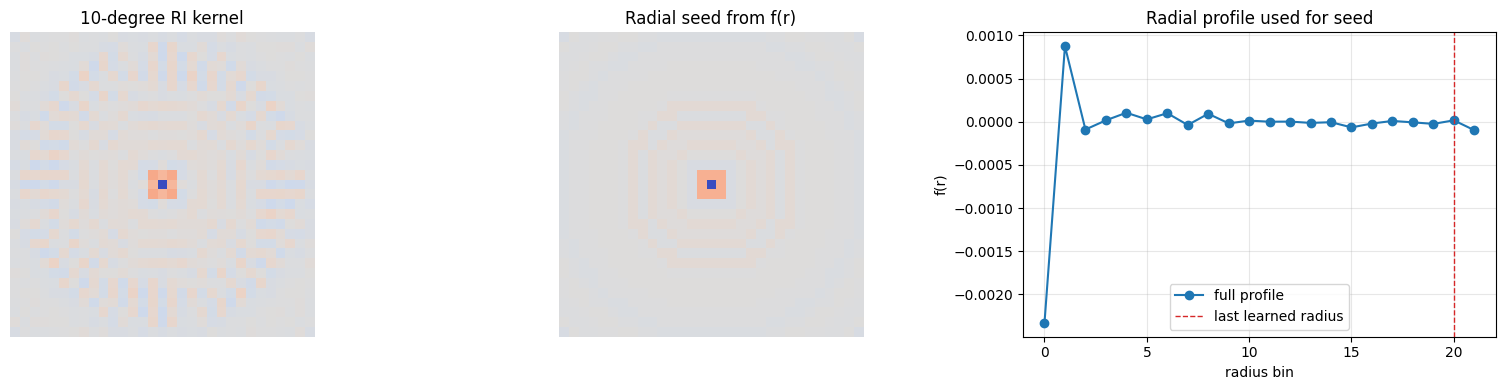

In [4]:
kernel_path = EXP_DIR / KERNEL_FILENAME
if not kernel_path.exists():
    raise FileNotFoundError(f"Missing kernel file: {kernel_path}")

base_kernel = np.load(kernel_path).astype(np.float32)
if base_kernel.ndim != 2:
    raise ValueError(f"Expected a 2D kernel, got shape={base_kernel.shape}")

rotated_kernels = [
    rotate(base_kernel, angle=angle, reshape=False, order=1, mode="nearest", prefilter=False)
    for angle in range(0, 360, SEED_ROTATION_STEP_DEG)
]
rotation_invariant_kernel = np.mean(np.stack(rotated_kernels, axis=0), axis=0).astype(np.float32)

f_seed_full, radius_bins = radial_profile_from_kernel(rotation_invariant_kernel)
basis_np = build_radial_basis(radius_bins)
seed_radial_kernel = np.einsum("r,rhw->hw", f_seed_full, basis_np).astype(np.float32)

full_radius_count = len(f_seed_full)
if FREEZE_OUTER_RADII:
    learnable_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
    f_tail_fixed = f_seed_full[learnable_len:].copy()
else:
    learnable_len = full_radius_count
    f_tail_fixed = np.zeros((0,), dtype=np.float32)

f_seed_learn = f_seed_full[:learnable_len].copy()

print(f"Original composite kernel shape: {base_kernel.shape}")
print(f"Rotation-invariant seed uses {len(rotated_kernels)} angles: 0..350 step {SEED_ROTATION_STEP_DEG}")
print(f"Total radial shells in kernel: {full_radius_count}")
print(f"Learnable shells: 0..{learnable_len - 1}")
if FREEZE_OUTER_RADII:
    print(f"Frozen outer shells: {learnable_len}..{full_radius_count - 1}")

print("\nSeed radial coefficients used as the initial f(r):")
for idx, value in enumerate(f_seed_learn):
    print(f"  f{idx:02d} = {value:+.7e}")

diff = rotation_invariant_kernel - seed_radial_kernel
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vmax = max(
    float(np.max(np.abs(rotation_invariant_kernel))),
    float(np.max(np.abs(seed_radial_kernel))),
) + 1e-12

axes[0].imshow(rotation_invariant_kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("10-degree RI kernel")
axes[0].axis("off")

axes[1].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Radial seed from f(r)")
axes[1].axis("off")

# axes[2].imshow(diff, cmap="coolwarm")
# axes[2].set_title("RI kernel - radial seed")
# axes[2].axis("off")

radius_axis = np.arange(len(f_seed_full))
axes[2].plot(radius_axis, f_seed_full, marker="o", linewidth=1.5, label="full profile")
axes[2].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=1, label="last learned radius")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Radial profile used for seed")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


In [5]:
data_root = resolve_data_root(EXP_DIR, DATA_ROOT)
print(f"Data root: {data_root}")

Xin_train, Xout_train = load_split(data_root, TRAIN_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
Xin_val, Xout_val = load_split(data_root, VAL_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)
Xin_test, Xout_test = load_split(data_root, TEST_SPLIT, RESIZE_PATCH, MAX_PER_CLASS)

print(f"Train split: Xin={Xin_train.shape}, Xout={Xout_train.shape}")
print(f"Val split  : Xin={Xin_val.shape}, Xout={Xout_val.shape}")
print(f"Test split : Xin={Xin_test.shape}, Xout={Xout_test.shape}")

X_train_t, y_train_t, y_train = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
X_val_t, y_val_t, y_val = make_xy_tensors(Xin_val, Xout_val, STANDARDIZE_PATCHES)
X_test_t, y_test_t, y_test = make_xy_tensors(Xin_test, Xout_test, STANDARDIZE_PATCHES)

seed_kernel_t = torch.from_numpy(seed_radial_kernel).to(DEVICE)
seed_train_resp = extract_responses(X_train_t, seed_kernel_t, BATCH_SIZE)
seed_val_resp = extract_responses(X_val_t, seed_kernel_t, BATCH_SIZE)
seed_test_resp = extract_responses(X_test_t, seed_kernel_t, BATCH_SIZE)

seed_mu = float(seed_train_resp.mean())
seed_std = float(seed_train_resp.std())
seed_std = seed_std if seed_std > 1e-8 else 1.0

seed_clf = LogisticRegression(max_iter=1000)
seed_clf.fit(((seed_train_resp - seed_mu) / seed_std).reshape(-1, 1), y_train)

seed_probs_train = seed_clf.predict_proba(((seed_train_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]
seed_probs_val = seed_clf.predict_proba(((seed_val_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]
seed_probs_test = seed_clf.predict_proba(((seed_test_resp - seed_mu) / seed_std).reshape(-1, 1))[:, 1]

seed_threshold_val, seed_val_acc_tuned = best_threshold_by_accuracy(y_val, seed_probs_val, THRESHOLD_GRID_SIZE)

seed_results = {
    "val_05": metrics_from_probs(y_val, seed_probs_val, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, seed_probs_val, threshold=seed_threshold_val),
    "test_05": metrics_from_probs(y_test, seed_probs_test, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, seed_probs_test, threshold=seed_threshold_val),
    "threshold_val": float(seed_threshold_val),
    "mu": seed_mu,
    "std": seed_std,
    "w": float(seed_clf.coef_[0, 0]),
    "b": float(seed_clf.intercept_[0]),
}

print("Seed radial-kernel baseline metrics:")
print(
    f"  Val  | AUC={seed_results['val_05']['auc']:.6f} ACC@0.5={seed_results['val_05']['acc']:.6f} "
    f"ACC@thr_val={seed_results['val_tuned']['acc']:.6f} (thr_val={seed_results['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={seed_results['test_05']['auc']:.6f} ACC@0.5={seed_results['test_05']['acc']:.6f} "
    f"ACC@thr_val={seed_results['test_tuned']['acc']:.6f}"
)


Data root: data/patches
Train split: Xin=(2900, 128, 128), Xout=(3430, 128, 128)
Val split  : Xin=(1080, 128, 128), Xout=(790, 128, 128)
Test split : Xin=(1040, 128, 128), Xout=(830, 128, 128)
Seed radial-kernel baseline metrics:
  Val  | AUC=0.889848 ACC@0.5=0.818182 ACC@thr_val=0.838503 (thr_val=0.420)
  Test | AUC=0.882471 ACC@0.5=0.800000 ACC@thr_val=0.802139


In [6]:
basis_t = torch.from_numpy(basis_np).to(DEVICE)
f_seed_learn_t = torch.from_numpy(f_seed_learn).to(DEVICE)
f_tail_fixed_t = torch.from_numpy(f_tail_fixed).to(DEVICE)
seed_norm = float(np.linalg.norm(f_seed_full))

def kernel_from_learnable(f_learn_t: torch.Tensor):
    if f_tail_fixed_t.numel() > 0:
        f_full_t = torch.cat([f_learn_t, f_tail_fixed_t], dim=0)
    else:
        f_full_t = f_learn_t
    kernel_t = torch.einsum("r,rhw->hw", f_full_t, basis_t)
    return kernel_t, f_full_t

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

f_learn = torch.nn.Parameter(f_seed_learn_t.clone())
head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

optimizer = torch.optim.Adam(
    [
        {"params": [f_learn], "lr": LR_F},
        {"params": [head_w, head_b], "lr": LR_HEAD},
    ]
)
loss_fn = torch.nn.BCEWithLogitsLoss()

best_state = None
best_val_auc = -float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        kernel_t, f_full_t = kernel_from_learnable(f_learn)
        feat = response_from_kernel(xb, kernel_t, RESPONSE_MODE)
        logits = head_w * feat + head_b

        loss_cls = loss_fn(logits, yb)
        loss_smooth = torch.mean((f_learn[1:] - f_learn[:-1]) ** 2) if f_learn.numel() > 1 else torch.tensor(0.0, device=DEVICE)
        loss_anchor = torch.mean((f_learn - f_seed_learn_t) ** 2)
        loss_scale = (torch.norm(f_full_t) - seed_norm) ** 2
        loss = loss_cls + LAMBDA_SMOOTH * loss_smooth + LAMBDA_ANCHOR * loss_anchor + LAMBDA_SCALE * loss_scale

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(loss.item()) * batch_n
        n_seen += batch_n

    kernel_val_t, _ = kernel_from_learnable(f_learn)
    val_resp = extract_responses(X_val_t, kernel_val_t.detach(), BATCH_SIZE)
    val_probs = sigmoid_np(float(head_w.detach().cpu()) * val_resp + float(head_b.detach().cpu()))
    val_metrics = metrics_from_probs(y_val, val_probs, threshold=0.5)

    history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(val_metrics["auc"]),
            "val_acc": float(val_metrics["acc"]),
            "optimizer_head_w": float(head_w.detach().cpu()),
            "optimizer_head_b": float(head_b.detach().cpu()),
        }
    )

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        best_state = {
            "epoch": int(epoch),
            "f_learn": f_learn.detach().cpu().clone(),
            "optimizer_head_w": float(head_w.detach().cpu()),
            "optimizer_head_b": float(head_b.detach().cpu()),
            "val_auc": float(val_metrics["auc"]),
            "val_acc": float(val_metrics["acc"]),
        }

    print(
        f"epoch={epoch:02d} "
        f"loss={history[-1]['loss']:.6f} "
        f"val_auc={val_metrics['auc']:.6f} "
        f"val_acc={val_metrics['acc']:.6f} "
        f"w={float(head_w.detach().cpu()):+.4f} "
        f"b={float(head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best checkpoint:")
print(best_state)

f_best = best_state["f_learn"].to(DEVICE)
optimizer_head_w_best = float(best_state["optimizer_head_w"])
optimizer_head_b_best = float(best_state["optimizer_head_b"])

kernel_best_t, f_best_full_t = kernel_from_learnable(f_best)
kernel_best = kernel_best_t.detach().cpu().numpy().astype(np.float32)
f_best_full = f_best_full_t.detach().cpu().numpy().astype(np.float32)

train_resp_best = extract_responses(X_train_t, kernel_best_t.detach(), BATCH_SIZE)
val_resp_best = extract_responses(X_val_t, kernel_best_t.detach(), BATCH_SIZE)
test_resp_best = extract_responses(X_test_t, kernel_best_t.detach(), BATCH_SIZE)

calib_mu_best = float(train_resp_best.mean())
calib_std_best = float(train_resp_best.std())
calib_std_best = calib_std_best if calib_std_best > 1e-8 else 1.0

calib_clf = LogisticRegression(max_iter=1000)
calib_clf.fit(((train_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1), y_train)

calib_w_best = float(calib_clf.coef_[0, 0])
calib_b_best = float(calib_clf.intercept_[0])

train_probs_best = calib_clf.predict_proba(((train_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1))[:, 1]
val_probs_best = calib_clf.predict_proba(((val_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1))[:, 1]
test_probs_best = calib_clf.predict_proba(((test_resp_best - calib_mu_best) / calib_std_best).reshape(-1, 1))[:, 1]

best_threshold_val, best_val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs_best, THRESHOLD_GRID_SIZE)

learned_results = {
    "val_05": metrics_from_probs(y_val, val_probs_best, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_best, threshold=best_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_best, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_best, threshold=best_threshold_val),
    "threshold_val": float(best_threshold_val),
    "best_epoch": int(best_state["epoch"]),
    "optimizer_head_w": optimizer_head_w_best,
    "optimizer_head_b": optimizer_head_b_best,
    "calib_mu": calib_mu_best,
    "calib_std": calib_std_best,
    "calib_w": calib_w_best,
    "calib_b": calib_b_best,
}

print("\nCalibrated learned radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results['val_05']['auc']:.6f} ACC@0.5={learned_results['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results['val_tuned']['acc']:.6f} (thr_val={learned_results['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results['test_05']['auc']:.6f} ACC@0.5={learned_results['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results['test_tuned']['acc']:.6f}"
)

print("\nOptimized learnable coefficients:")
for idx, value in enumerate(f_best_full[:learnable_len]):
    print(f"  f{idx:02d} = {value:+.7e}")

results_summary = {
    "seed": seed_results,
    "learned": learned_results,
    "f_seed_full": [float(x) for x in f_seed_full],
    "f_learned_full": [float(x) for x in f_best_full],
    "history": history,
    "response_mode": RESPONSE_MODE,
    "standardize_patches": bool(STANDARDIZE_PATCHES),
    "freeze_outer_radii": bool(FREEZE_OUTER_RADII),
    "learned_radius_max": int(learnable_len - 1),
}

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "f_seed_full.npy", f_seed_full.astype(np.float32))
    np.save(OUT_DIR / "f_learned_full.npy", f_best_full.astype(np.float32))
    np.save(OUT_DIR / "kernel_seed_radial.npy", seed_radial_kernel.astype(np.float32))
    np.save(OUT_DIR / "kernel_learned_radial.npy", kernel_best.astype(np.float32))
    (OUT_DIR / "radial_single_kernel_summary.json").write_text(json.dumps(results_summary, indent=2))
    print(f"\nSaved kernel artifacts to {OUT_DIR}")


KeyboardInterrupt: 

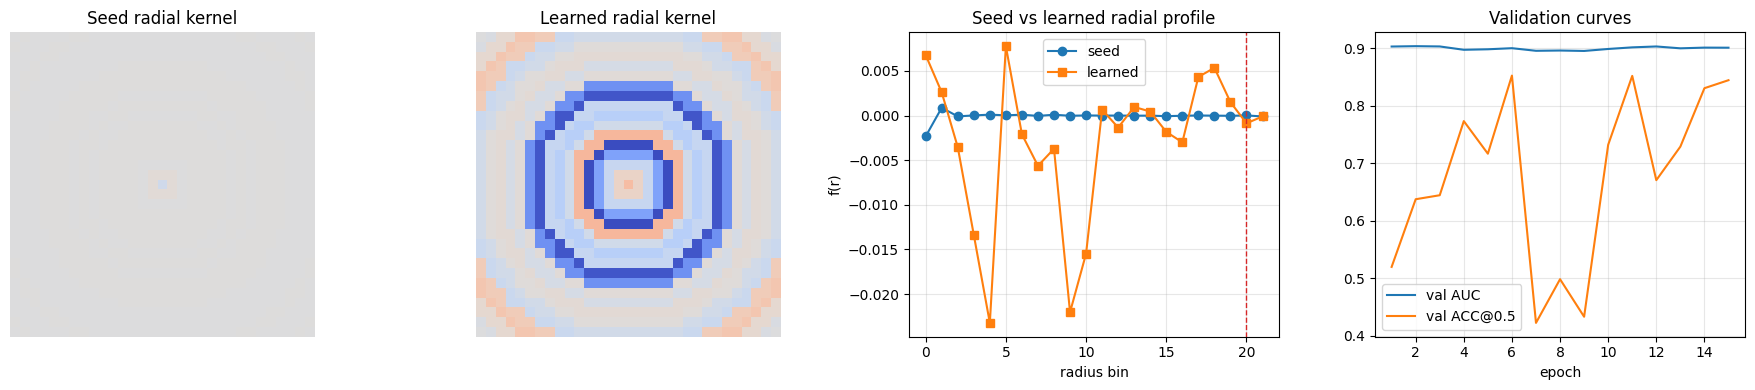

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

vmax = max(float(np.max(np.abs(seed_radial_kernel))), float(np.max(np.abs(kernel_best)))) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Learned radial kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.5, label="seed")
axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.5, label="learned")
axes[2].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=1)
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Seed vs learned radial profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

epochs = np.array([row["epoch"] for row in history], dtype=int)
val_auc = np.array([row["val_auc"] for row in history], dtype=np.float32)
val_acc = np.array([row["val_acc"] for row in history], dtype=np.float32)
axes[3].plot(epochs, val_auc, label="val AUC")
axes[3].plot(epochs, val_acc, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Validation curves")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()


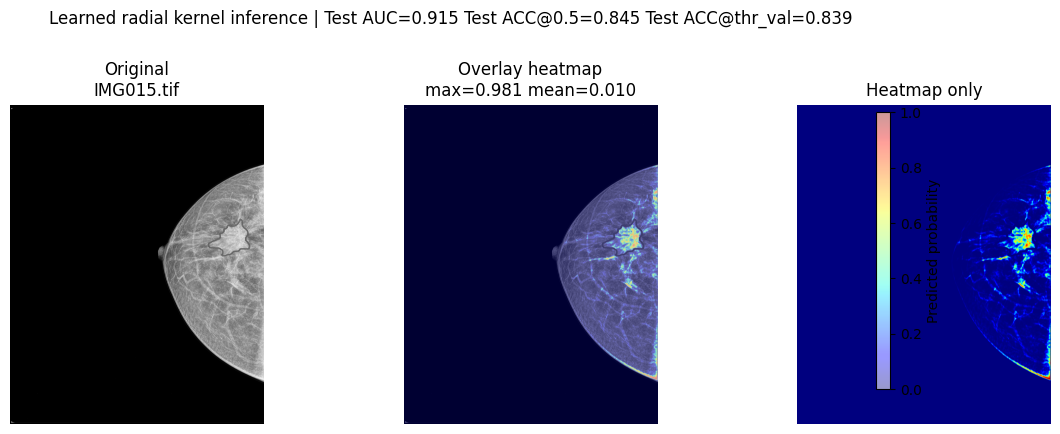

Saved heatmap figure: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/IMG015_learned_radial_heatmap.png
Saved probability map: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/IMG015_learned_radial_prob_map.npy


In [ ]:
example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
img_arr = np.array(Image.open(example_path).convert("L"), dtype=np.float32) / 255.0

x_img_t = to_tensor_batch(img_arr[None, ...].astype(np.float32), torch.device("cpu"))
if STANDARDIZE_PATCHES:
    x_img_t = patch_standardize(x_img_t)

with torch.no_grad():
    xb = x_img_t.to(DEVICE, non_blocking=True)
    out = F.conv2d(xb, torch.from_numpy(kernel_best).to(DEVICE)[None, None], padding=kernel_best.shape[-1] // 2)[0, 0]
    feature_map = out.abs().detach().cpu().numpy().astype(np.float32)

prob_map = sigmoid_np(calib_w_best * ((feature_map - calib_mu_best) / calib_std_best) + calib_b_best).astype(np.float32)
prob_map_vis = gaussian_filter(prob_map, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map

image_score_max = float(prob_map.max())
image_score_mean = float(prob_map.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(img_arr, cmap="gray")
axes[0].set_title(f"Original\n{example_path.name}")
axes[0].axis("off")

axes[1].imshow(img_arr, cmap="gray")
im = axes[1].imshow(prob_map_vis, cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[1].set_title(
    "Overlay heatmap\n"
    f"max={image_score_max:.3f} mean={image_score_mean:.3f}"
)
axes[1].axis("off")

axes[2].imshow(prob_map_vis, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title("Heatmap only")
axes[2].axis("off")

fig.suptitle(
    "Learned radial kernel inference | "
    f"Test AUC={learned_results['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={learned_results['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

if SAVE_ARTIFACTS:
    heatmap_fig_path = OUT_DIR / f"{example_path.stem}_learned_radial_heatmap.png"
    prob_map_path = OUT_DIR / f"{example_path.stem}_learned_radial_prob_map.npy"
    fig.savefig(heatmap_fig_path, dpi=260, bbox_inches="tight")
    np.save(prob_map_path, prob_map)
    print(f"Saved heatmap figure: {heatmap_fig_path}")
    print(f"Saved probability map: {prob_map_path}")


mono epoch=01 loss=0.696546 val_auc=0.908617 val_acc=0.848663 w=+0.4273 b=-0.9445
mono epoch=02 loss=0.630696 val_auc=0.908632 val_acc=0.841711 w=+0.4805 b=-1.0615
mono epoch=03 loss=0.622794 val_auc=0.908719 val_acc=0.837968 w=+0.5077 b=-1.2428
mono epoch=04 loss=0.613852 val_auc=0.908789 val_acc=0.852941 w=+0.5653 b=-1.4165
mono epoch=05 loss=0.604278 val_auc=0.908878 val_acc=0.855080 w=+0.6074 b=-1.6202
mono epoch=06 loss=0.594546 val_auc=0.908981 val_acc=0.855080 w=+0.6473 b=-1.8302
mono epoch=07 loss=0.585003 val_auc=0.909083 val_acc=0.849733 w=+0.6811 b=-2.0483
mono epoch=08 loss=0.576455 val_auc=0.909208 val_acc=0.822995 w=+0.7314 b=-2.2569
mono epoch=09 loss=0.568180 val_auc=0.909264 val_acc=0.852406 w=+0.7436 b=-2.4844
mono epoch=10 loss=0.559538 val_auc=0.909383 val_acc=0.849733 w=+0.7677 b=-2.7041
mono epoch=11 loss=0.551708 val_auc=0.909514 val_acc=0.843316 w=+0.7889 b=-2.9236
mono epoch=12 loss=0.545748 val_auc=0.909652 val_acc=0.843316 w=+0.8315 b=-3.1159
mono epoch=13 lo

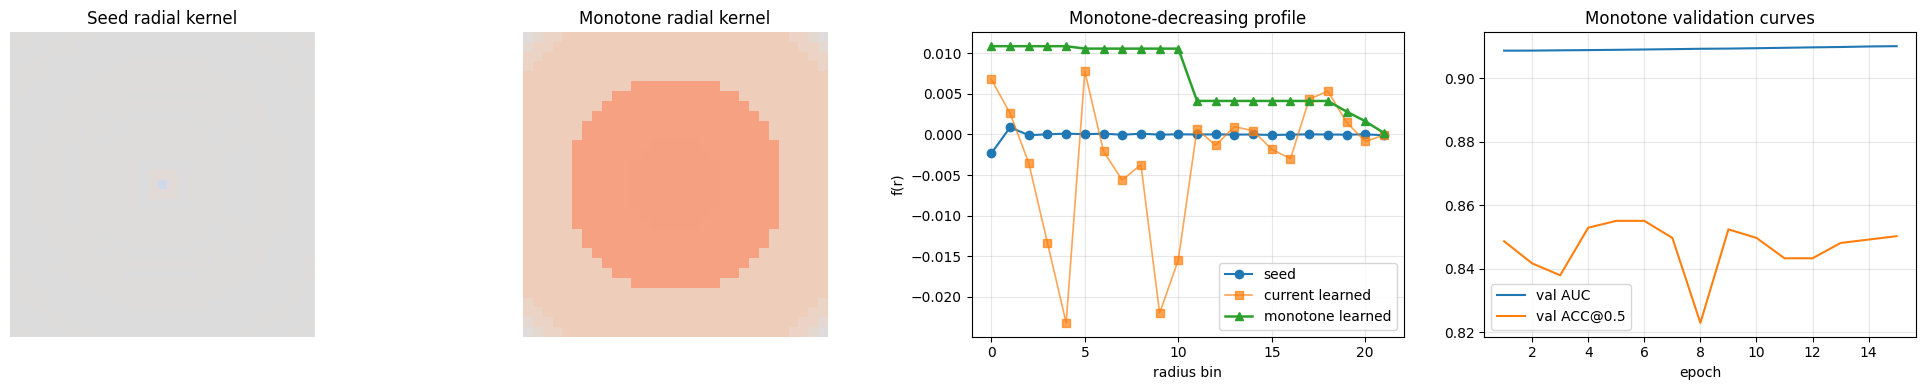

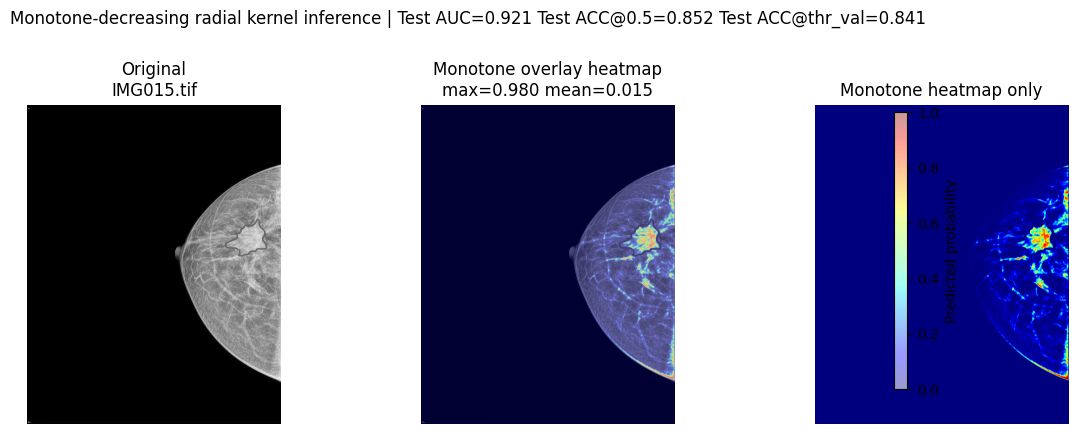


Saved monotone artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/monotone_decreasing


In [ ]:

# Optional: monotone-decreasing radial fit.
# This version is most natural with absolute response modes such as `abs_max` or `mean_abs`,
# because the patch feature already discards the kernel sign.
from sklearn.isotonic import IsotonicRegression

MONO_EPOCHS = EPOCHS
MONO_LR_PROFILE = LR_F * 0.5
MONO_LR_HEAD = LR_HEAD
MONO_LAMBDA_ANCHOR = 5e-2
MONO_LAMBDA_SCALE = LAMBDA_SCALE
MONO_LAMBDA_EDGE = 5e-2
MONO_OUT_DIR = OUT_DIR / "monotone_decreasing"
MONO_OUT_DIR.mkdir(parents=True, exist_ok=True)

if RESPONSE_MODE not in {"abs_max", "mean_abs"}:
    raise ValueError("This monotone cell expects an absolute response mode such as 'abs_max' or 'mean_abs'.")

mono_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
mono_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

mono_len = full_radius_count
mono_radius = np.arange(mono_len, dtype=np.float32)
mono_reference = np.abs(f_best_full[:mono_len] if "f_best_full" in globals() else f_seed_full[:mono_len]).astype(np.float32)
mono_iso = IsotonicRegression(increasing=False, out_of_bounds="clip")
mono_init = mono_iso.fit_transform(mono_radius, mono_reference).astype(np.float32)
mono_init = np.maximum(mono_init, 0.0)


def inverse_softplus_np(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.maximum(x, 1e-6)
    return np.where(x > 20.0, x, np.log(np.expm1(x)))


def monotone_profile_from_raw(raw_delta_t: torch.Tensor):
    delta_t = F.softplus(raw_delta_t)
    return torch.flip(torch.cumsum(torch.flip(delta_t, dims=[0]), dim=0), dims=[0])


mono_delta_init = np.empty_like(mono_init)
mono_delta_init[:-1] = np.maximum(mono_init[:-1] - mono_init[1:], 1e-6)
mono_delta_init[-1] = max(float(mono_init[-1]), 1e-6)

mono_raw_delta = torch.nn.Parameter(torch.from_numpy(inverse_softplus_np(mono_delta_init)).to(DEVICE))
mono_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
mono_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))
if "learned_results" in globals():
    mono_head_w.data.fill_(float(learned_results["optimizer_head_w"]))
    mono_head_b.data.fill_(float(learned_results["optimizer_head_b"]))

mono_ref_t = torch.from_numpy(mono_init).to(DEVICE)
mono_ref_norm = float(np.linalg.norm(mono_init))
mono_optimizer = torch.optim.Adam(
    [
        {"params": [mono_raw_delta], "lr": MONO_LR_PROFILE},
        {"params": [mono_head_w, mono_head_b], "lr": MONO_LR_HEAD},
    ]
)
mono_loss_fn = torch.nn.BCEWithLogitsLoss()
mono_best_state = None
mono_best_val_auc = -float("inf")
mono_history = []

for epoch in range(1, MONO_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in mono_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        mono_profile_t = monotone_profile_from_raw(mono_raw_delta)
        mono_kernel_t = torch.einsum("r,rhw->hw", mono_profile_t, mono_basis_t)
        mono_feat = response_from_kernel(xb, mono_kernel_t, RESPONSE_MODE)
        mono_logits = mono_head_w * mono_feat + mono_head_b

        mono_loss_cls = mono_loss_fn(mono_logits, yb)
        mono_loss_anchor = torch.mean((mono_profile_t - mono_ref_t) ** 2)
        mono_loss_smooth = torch.mean((mono_profile_t[1:] - mono_profile_t[:-1]) ** 2)
        mono_loss_scale = (torch.norm(mono_profile_t) - mono_ref_norm) ** 2
        mono_loss_edge = mono_profile_t[-1] ** 2
        mono_loss = (
            mono_loss_cls
            + MONO_LAMBDA_ANCHOR * mono_loss_anchor
            + LAMBDA_SMOOTH * mono_loss_smooth
            + MONO_LAMBDA_SCALE * mono_loss_scale
            + MONO_LAMBDA_EDGE * mono_loss_edge
        )

        mono_optimizer.zero_grad()
        mono_loss.backward()
        mono_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(mono_loss.item()) * batch_n
        n_seen += batch_n

    mono_profile_eval_t = monotone_profile_from_raw(mono_raw_delta)
    mono_kernel_eval_t = torch.einsum("r,rhw->hw", mono_profile_eval_t, mono_basis_t)
    mono_val_resp = extract_responses(X_val_t, mono_kernel_eval_t.detach(), BATCH_SIZE)
    mono_val_probs = sigmoid_np(float(mono_head_w.detach().cpu()) * mono_val_resp + float(mono_head_b.detach().cpu()))
    mono_val_metrics = metrics_from_probs(y_val, mono_val_probs, threshold=0.5)

    mono_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(mono_val_metrics["auc"]),
            "val_acc": float(mono_val_metrics["acc"]),
            "optimizer_head_w": float(mono_head_w.detach().cpu()),
            "optimizer_head_b": float(mono_head_b.detach().cpu()),
        }
    )

    if mono_val_metrics["auc"] > mono_best_val_auc:
        mono_best_val_auc = mono_val_metrics["auc"]
        mono_best_state = {
            "epoch": int(epoch),
            "raw_delta": mono_raw_delta.detach().cpu().clone(),
            "optimizer_head_w": float(mono_head_w.detach().cpu()),
            "optimizer_head_b": float(mono_head_b.detach().cpu()),
            "val_auc": float(mono_val_metrics["auc"]),
            "val_acc": float(mono_val_metrics["acc"]),
        }

    print(
        f"mono epoch={epoch:02d} "
        f"loss={mono_history[-1]['loss']:.6f} "
        f"val_auc={mono_val_metrics['auc']:.6f} "
        f"val_acc={mono_val_metrics['acc']:.6f} "
        f"w={float(mono_head_w.detach().cpu()):+.4f} "
        f"b={float(mono_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best monotone checkpoint:")
print(mono_best_state)

mono_raw_best = mono_best_state["raw_delta"].to(DEVICE)
mono_optimizer_head_w_best = float(mono_best_state["optimizer_head_w"])
mono_optimizer_head_b_best = float(mono_best_state["optimizer_head_b"])

with torch.no_grad():
    f_best_full_mono_t = monotone_profile_from_raw(mono_raw_best)
    kernel_best_mono_t = torch.einsum("r,rhw->hw", f_best_full_mono_t, mono_basis_t)

f_best_full_mono = f_best_full_mono_t.detach().cpu().numpy().astype(np.float32)
kernel_best_mono = kernel_best_mono_t.detach().cpu().numpy().astype(np.float32)

train_resp_mono = extract_responses(X_train_t, kernel_best_mono_t.detach(), BATCH_SIZE)
val_resp_mono = extract_responses(X_val_t, kernel_best_mono_t.detach(), BATCH_SIZE)
test_resp_mono = extract_responses(X_test_t, kernel_best_mono_t.detach(), BATCH_SIZE)

calib_mu_mono = float(train_resp_mono.mean())
calib_std_mono = float(train_resp_mono.std())
calib_std_mono = calib_std_mono if calib_std_mono > 1e-8 else 1.0

calib_clf_mono = LogisticRegression(max_iter=1000)
calib_clf_mono.fit(((train_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1), y_train)

calib_w_mono = float(calib_clf_mono.coef_[0, 0])
calib_b_mono = float(calib_clf_mono.intercept_[0])

train_probs_mono = calib_clf_mono.predict_proba(((train_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1))[:, 1]
val_probs_mono = calib_clf_mono.predict_proba(((val_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1))[:, 1]
test_probs_mono = calib_clf_mono.predict_proba(((test_resp_mono - calib_mu_mono) / calib_std_mono).reshape(-1, 1))[:, 1]

mono_threshold_val, mono_val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs_mono, THRESHOLD_GRID_SIZE)

learned_results_mono = {
    "val_05": metrics_from_probs(y_val, val_probs_mono, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_mono, threshold=mono_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_mono, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_mono, threshold=mono_threshold_val),
    "threshold_val": float(mono_threshold_val),
    "best_epoch": int(mono_best_state["epoch"]),
    "optimizer_head_w": mono_optimizer_head_w_best,
    "optimizer_head_b": mono_optimizer_head_b_best,
    "calib_mu": calib_mu_mono,
    "calib_std": calib_std_mono,
    "calib_w": calib_w_mono,
    "calib_b": calib_b_mono,
}

print("\nCalibrated monotone radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_mono['val_05']['auc']:.6f} ACC@0.5={learned_results_mono['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_mono['val_tuned']['acc']:.6f} (thr_val={learned_results_mono['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_mono['test_05']['auc']:.6f} ACC@0.5={learned_results_mono['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_mono['test_tuned']['acc']:.6f}"
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
mono_vmax = max(
    float(np.max(np.abs(seed_radial_kernel))),
    float(np.max(np.abs(kernel_best_mono))),
    float(np.max(np.abs(kernel_best))) if "kernel_best" in globals() else 0.0,
) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-mono_vmax, vmax=mono_vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best_mono, cmap="coolwarm", vmin=-mono_vmax, vmax=mono_vmax)
axes[1].set_title("Monotone radial kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.5, label="seed")
if "f_best_full" in globals():
    axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.2, alpha=0.7, label="current learned")
axes[2].plot(np.arange(len(f_best_full_mono)), f_best_full_mono, marker="^", linewidth=1.8, label="monotone learned")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Monotone-decreasing profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

mono_epochs = np.array([row["epoch"] for row in mono_history], dtype=int)
mono_val_auc = np.array([row["val_auc"] for row in mono_history], dtype=np.float32)
mono_val_acc = np.array([row["val_acc"] for row in mono_history], dtype=np.float32)
axes[3].plot(mono_epochs, mono_val_auc, label="val AUC")
axes[3].plot(mono_epochs, mono_val_acc, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Monotone validation curves")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

mono_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
mono_img_arr = np.array(Image.open(mono_example_path).convert("L"), dtype=np.float32) / 255.0
mono_x_img_t = to_tensor_batch(mono_img_arr[None, ...].astype(np.float32), torch.device("cpu"))
if STANDARDIZE_PATCHES:
    mono_x_img_t = patch_standardize(mono_x_img_t)

with torch.no_grad():
    mono_xb = mono_x_img_t.to(DEVICE, non_blocking=True)
    mono_out = F.conv2d(mono_xb, torch.from_numpy(kernel_best_mono).to(DEVICE)[None, None], padding=kernel_best_mono.shape[-1] // 2)[0, 0]
    mono_feature_map = mono_out.abs().detach().cpu().numpy().astype(np.float32)

prob_map_mono = sigmoid_np(calib_w_mono * ((mono_feature_map - calib_mu_mono) / calib_std_mono) + calib_b_mono).astype(np.float32)
prob_map_vis_mono = gaussian_filter(prob_map_mono, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map_mono
mono_score_max = float(prob_map_mono.max())
mono_score_mean = float(prob_map_mono.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(mono_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{mono_example_path.name}")
axes[0].axis("off")

axes[1].imshow(mono_img_arr, cmap="gray")
mono_im = axes[1].imshow(prob_map_vis_mono, cmap="jet", alpha=DENSE_OVERLAY_ALPHA, vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[1].set_title(
    "Monotone overlay heatmap\n"
    f"max={mono_score_max:.3f} mean={mono_score_mean:.3f}"
)
axes[1].axis("off")

axes[2].imshow(prob_map_vis_mono, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title("Monotone heatmap only")
axes[2].axis("off")

fig.suptitle(
    "Monotone-decreasing radial kernel inference | "
    f"Test AUC={learned_results_mono['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_mono['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={learned_results_mono['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(mono_im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

mono_summary = {
    "reference_profile_abs": [float(x) for x in mono_reference],
    "f_monotone_full": [float(x) for x in f_best_full_mono],
    "learned_monotone": learned_results_mono,
    "history_monotone": mono_history,
    "response_mode": RESPONSE_MODE,
}

if SAVE_ARTIFACTS:
    np.save(MONO_OUT_DIR / "f_monotone_full.npy", f_best_full_mono.astype(np.float32))
    np.save(MONO_OUT_DIR / "kernel_monotone_radial.npy", kernel_best_mono.astype(np.float32))
    np.save(MONO_OUT_DIR / f"{mono_example_path.stem}_monotone_prob_map.npy", prob_map_mono)
    fig.savefig(MONO_OUT_DIR / f"{mono_example_path.stem}_monotone_heatmap.png", dpi=260, bbox_inches="tight")
    (MONO_OUT_DIR / "monotone_summary.json").write_text(json.dumps(mono_summary, indent=2))
    print(f"\nSaved monotone artifacts to {MONO_OUT_DIR}")


signed epoch=01 loss=6.366508 val_auc=0.117882 val_acc=0.389305 w=+0.6766 b=+0.0729
signed epoch=02 loss=1.091663 val_auc=0.569235 val_acc=0.498930 w=+0.5812 b=+0.0854
signed epoch=03 loss=0.870455 val_auc=0.405724 val_acc=0.470588 w=+0.5236 b=-0.0211
signed epoch=04 loss=0.816319 val_auc=0.783319 val_acc=0.591444 w=+0.4700 b=-0.1642
signed epoch=05 loss=0.770602 val_auc=0.596479 val_acc=0.553476 w=+0.4195 b=-0.3150
signed epoch=06 loss=0.730265 val_auc=0.842984 val_acc=0.637968 w=+0.3796 b=-0.4667
signed epoch=07 loss=0.682965 val_auc=0.883201 val_acc=0.696257 w=+0.3579 b=-0.6051
signed epoch=08 loss=0.657921 val_auc=0.897005 val_acc=0.734759 w=+0.3529 b=-0.7330
signed epoch=09 loss=0.650569 val_auc=0.888868 val_acc=0.826203 w=+0.3551 b=-0.8503
signed epoch=10 loss=0.644090 val_auc=0.885563 val_acc=0.797326 w=+0.3635 b=-0.9506
signed epoch=11 loss=0.638307 val_auc=0.893190 val_acc=0.834225 w=+0.3730 b=-1.0538
signed epoch=12 loss=0.632671 val_auc=0.888966 val_acc=0.822995 w=+0.3828 b=

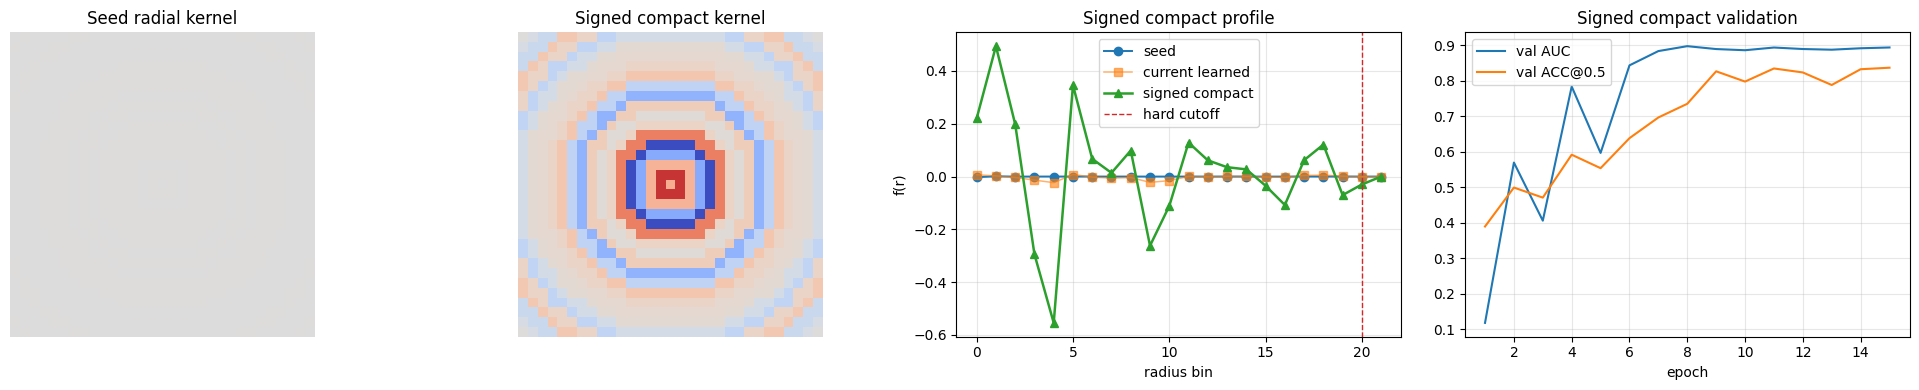

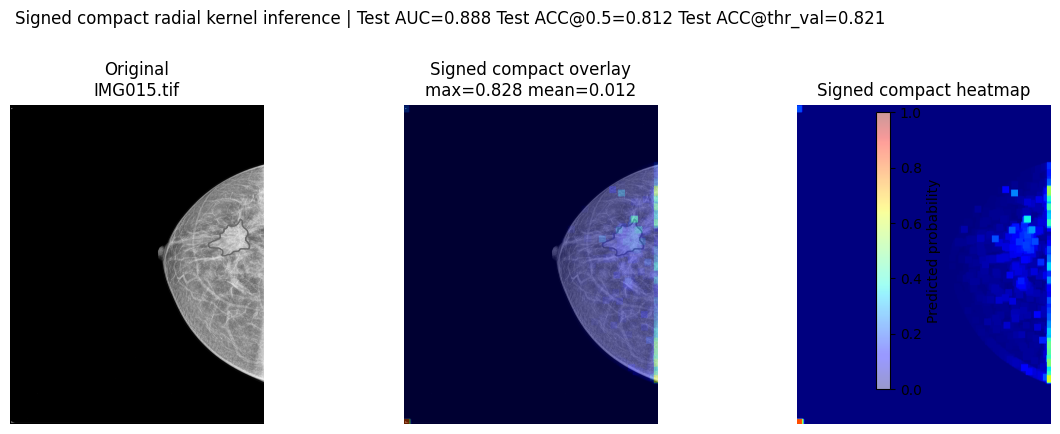


Saved signed compact artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20


In [ ]:

# Optional: signed, compact, more identifiable radial fit.
# This cell addresses the main ambiguities of the original setup:
# 1) use a signed response instead of abs_max
# 2) set f(r)=0 for r > LEARNED_RADIUS_MAX
# 3) add monotone/decay regularization on |f(r)|
# 4) normalize kernel scale and fix the sign convention by forcing f(0) > 0

SIGNED_RESPONSE_NAME = "signed_peak"
SIGNED_EPOCHS = EPOCHS
SIGNED_LR_PROFILE = LR_F * 0.5
SIGNED_LR_HEAD = LR_HEAD
SIGNED_LAMBDA_ANCHOR = 5e-2
SIGNED_LAMBDA_SMOOTH = LAMBDA_SMOOTH
SIGNED_LAMBDA_MONO = 1e-1
SIGNED_LAMBDA_DECAY = 1e-1
SIGNED_LAMBDA_EDGE = 5e-2
SIGNED_OUT_DIR = OUT_DIR / f"signed_compact_r{LEARNED_RADIUS_MAX}"
SIGNED_OUT_DIR.mkdir(parents=True, exist_ok=True)

signed_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
signed_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

compact_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
zero_tail_len = full_radius_count - compact_len
zero_tail_t = torch.zeros(zero_tail_len, dtype=torch.float32, device=DEVICE)
radius_support_t = torch.arange(compact_len, dtype=torch.float32, device=DEVICE)
if compact_len > 1:
    radius_support_t = radius_support_t / float(compact_len - 1)

reference_source = f_best_full if "f_best_full" in globals() else f_seed_full
reference_full = np.zeros((full_radius_count,), dtype=np.float32)
reference_full[:compact_len] = reference_source[:compact_len]
if reference_full[0] < 0:
    reference_full[:compact_len] *= -1.0
ref_norm = float(np.linalg.norm(reference_full[:compact_len]))
if ref_norm < 1e-8:
    reference_full[0] = 1.0
    ref_norm = 1.0
reference_full[:compact_len] /= ref_norm
reference_support = reference_full[:compact_len].copy()
reference_support_t = torch.from_numpy(reference_support).to(DEVICE)


def inverse_softplus_scalar(x: float):
    x = max(float(x), 1e-6)
    return x if x > 20.0 else float(np.log(np.expm1(x)))


def signed_peak_response(x_t: torch.Tensor, kernel2d_t: torch.Tensor):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    flat = out[:, 0].reshape(out.shape[0], -1)
    idx = flat.abs().argmax(dim=1, keepdim=True)
    return flat.gather(1, idx).squeeze(1)


@torch.no_grad()
def extract_signed_peak_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = signed_peak_response(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


@torch.no_grad()
def dense_signed_peak_feature_map(x_t: torch.Tensor, kernel2d_t: torch.Tensor, pool_window: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    xb = x_t.to(DEVICE, non_blocking=True)
    out = F.conv2d(xb, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    abs_out = out.abs()

    pool_window = max(int(pool_window), 1)
    if pool_window == 1:
        peak_map = out
    else:
        pad = pool_window // 2
        _, idx = F.max_pool2d(abs_out, kernel_size=pool_window, stride=1, padding=pad, return_indices=True)
        flat_out = out.reshape(out.shape[0], out.shape[1], -1)
        peak_map = flat_out.gather(2, idx.reshape(idx.shape[0], idx.shape[1], -1)).reshape_as(idx)
        peak_map = peak_map[..., : out.shape[-2], : out.shape[-1]]

    return (
        out[0, 0].detach().cpu().numpy().astype(np.float32),
        peak_map[0, 0].detach().cpu().numpy().astype(np.float32),
    )


def build_signed_compact_kernel(center_param_t: torch.Tensor, rest_param_t: torch.Tensor):
    center_value = F.softplus(center_param_t).reshape(1) + 1e-6
    if compact_len > 1:
        support_t = torch.cat([center_value, rest_param_t], dim=0)
    else:
        support_t = center_value
    full_t = torch.cat([support_t, zero_tail_t], dim=0) if zero_tail_len > 0 else support_t
    full_t = full_t / (torch.norm(full_t) + 1e-8)
    kernel_t = torch.einsum("r,rhw->hw", full_t, signed_basis_t)
    return kernel_t, full_t, support_t


center_init = float(reference_support[0])
rest_init = reference_support[1:].astype(np.float32) if compact_len > 1 else np.zeros((0,), dtype=np.float32)

signed_center_param = torch.nn.Parameter(
    torch.tensor(inverse_softplus_scalar(center_init), dtype=torch.float32, device=DEVICE)
)
signed_rest_param = torch.nn.Parameter(torch.from_numpy(rest_init).to(DEVICE))
signed_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
signed_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

signed_optimizer = torch.optim.Adam(
    [
        {"params": [signed_center_param, signed_rest_param], "lr": SIGNED_LR_PROFILE},
        {"params": [signed_head_w, signed_head_b], "lr": SIGNED_LR_HEAD},
    ]
)
signed_loss_fn = torch.nn.BCEWithLogitsLoss()
signed_best_state = None
signed_best_val_auc = -float("inf")
signed_history = []

for epoch in range(1, SIGNED_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in signed_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        signed_kernel_t, signed_full_t, signed_support_t = build_signed_compact_kernel(
            signed_center_param,
            signed_rest_param,
        )
        signed_feat = signed_peak_response(xb, signed_kernel_t)
        signed_logits = signed_head_w * signed_feat + signed_head_b

        signed_loss_cls = signed_loss_fn(signed_logits, yb)
        signed_loss_anchor = torch.mean((signed_support_t - reference_support_t) ** 2)
        signed_loss_smooth = (
            torch.mean((signed_support_t[1:] - signed_support_t[:-1]) ** 2)
            if compact_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        signed_abs_support = signed_support_t.abs()
        signed_loss_mono = (
            torch.mean(torch.relu(signed_abs_support[1:] - signed_abs_support[:-1]) ** 2)
            if compact_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        signed_loss_decay = torch.mean((radius_support_t ** 2) * (signed_support_t ** 2))
        signed_loss_edge = signed_support_t[-1] ** 2
        signed_loss = (
            signed_loss_cls
            + SIGNED_LAMBDA_ANCHOR * signed_loss_anchor
            + SIGNED_LAMBDA_SMOOTH * signed_loss_smooth
            + SIGNED_LAMBDA_MONO * signed_loss_mono
            + SIGNED_LAMBDA_DECAY * signed_loss_decay
            + SIGNED_LAMBDA_EDGE * signed_loss_edge
        )

        signed_optimizer.zero_grad()
        signed_loss.backward()
        signed_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(signed_loss.item()) * batch_n
        n_seen += batch_n

    signed_kernel_val_t, _, _ = build_signed_compact_kernel(
        signed_center_param,
        signed_rest_param,
    )
    signed_val_resp = extract_signed_peak_responses(X_val_t, signed_kernel_val_t.detach(), BATCH_SIZE)
    signed_val_probs = sigmoid_np(
        float(signed_head_w.detach().cpu()) * signed_val_resp + float(signed_head_b.detach().cpu())
    )
    signed_val_metrics = metrics_from_probs(y_val, signed_val_probs, threshold=0.5)

    signed_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(signed_val_metrics["auc"]),
            "val_acc": float(signed_val_metrics["acc"]),
            "optimizer_head_w": float(signed_head_w.detach().cpu()),
            "optimizer_head_b": float(signed_head_b.detach().cpu()),
        }
    )

    if signed_val_metrics["auc"] > signed_best_val_auc:
        signed_best_val_auc = signed_val_metrics["auc"]
        signed_best_state = {
            "epoch": int(epoch),
            "center_param": signed_center_param.detach().cpu().clone(),
            "rest_param": signed_rest_param.detach().cpu().clone(),
            "optimizer_head_w": float(signed_head_w.detach().cpu()),
            "optimizer_head_b": float(signed_head_b.detach().cpu()),
            "val_auc": float(signed_val_metrics["auc"]),
            "val_acc": float(signed_val_metrics["acc"]),
        }

    print(
        f"signed epoch={epoch:02d} "
        f"loss={signed_history[-1]['loss']:.6f} "
        f"val_auc={signed_val_metrics['auc']:.6f} "
        f"val_acc={signed_val_metrics['acc']:.6f} "
        f"w={float(signed_head_w.detach().cpu()):+.4f} "
        f"b={float(signed_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best signed compact checkpoint:")
print(signed_best_state)

signed_center_best = signed_best_state["center_param"].to(DEVICE)
signed_rest_best = signed_best_state["rest_param"].to(DEVICE)
signed_optimizer_head_w_best = float(signed_best_state["optimizer_head_w"])
signed_optimizer_head_b_best = float(signed_best_state["optimizer_head_b"])

with torch.no_grad():
    kernel_best_signed_t, f_best_full_signed_t, f_best_support_signed_t = build_signed_compact_kernel(
        signed_center_best,
        signed_rest_best,
    )

kernel_best_signed = kernel_best_signed_t.detach().cpu().numpy().astype(np.float32)
f_best_full_signed = f_best_full_signed_t.detach().cpu().numpy().astype(np.float32)
f_best_support_signed = f_best_support_signed_t.detach().cpu().numpy().astype(np.float32)

train_resp_signed = extract_signed_peak_responses(X_train_t, kernel_best_signed_t.detach(), BATCH_SIZE)
val_resp_signed = extract_signed_peak_responses(X_val_t, kernel_best_signed_t.detach(), BATCH_SIZE)
test_resp_signed = extract_signed_peak_responses(X_test_t, kernel_best_signed_t.detach(), BATCH_SIZE)

calib_mu_signed = float(train_resp_signed.mean())
calib_std_signed = float(train_resp_signed.std())
calib_std_signed = calib_std_signed if calib_std_signed > 1e-8 else 1.0

calib_clf_signed = LogisticRegression(max_iter=1000)
calib_clf_signed.fit(((train_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1), y_train)

calib_w_signed = float(calib_clf_signed.coef_[0, 0])
calib_b_signed = float(calib_clf_signed.intercept_[0])

train_probs_signed = calib_clf_signed.predict_proba(((train_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1))[:, 1]
val_probs_signed = calib_clf_signed.predict_proba(((val_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1))[:, 1]
test_probs_signed = calib_clf_signed.predict_proba(((test_resp_signed - calib_mu_signed) / calib_std_signed).reshape(-1, 1))[:, 1]

signed_threshold_val, signed_val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs_signed, THRESHOLD_GRID_SIZE)

learned_results_signed = {
    "val_05": metrics_from_probs(y_val, val_probs_signed, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_signed, threshold=signed_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_signed, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_signed, threshold=signed_threshold_val),
    "threshold_val": float(signed_threshold_val),
    "best_epoch": int(signed_best_state["epoch"]),
    "optimizer_head_w": signed_optimizer_head_w_best,
    "optimizer_head_b": signed_optimizer_head_b_best,
    "calib_mu": calib_mu_signed,
    "calib_std": calib_std_signed,
    "calib_w": calib_w_signed,
    "calib_b": calib_b_signed,
    "response_mode": SIGNED_RESPONSE_NAME,
    "compact_radius_max": int(compact_len - 1),
}

print("\nCalibrated signed compact radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_signed['val_05']['auc']:.6f} ACC@0.5={learned_results_signed['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_signed['val_tuned']['acc']:.6f} (thr_val={learned_results_signed['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_signed['test_05']['auc']:.6f} ACC@0.5={learned_results_signed['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_signed['test_tuned']['acc']:.6f}"
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
signed_vmax = max(
    float(np.max(np.abs(seed_radial_kernel))),
    float(np.max(np.abs(kernel_best_signed))),
    float(np.max(np.abs(kernel_best))) if "kernel_best" in globals() else 0.0,
) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-signed_vmax, vmax=signed_vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best_signed, cmap="coolwarm", vmin=-signed_vmax, vmax=signed_vmax)
axes[1].set_title("Signed compact kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.4, label="seed")
if "f_best_full" in globals():
    axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.1, alpha=0.6, label="current learned")
axes[2].plot(np.arange(len(f_best_full_signed)), f_best_full_signed, marker="^", linewidth=1.8, label="signed compact")
axes[2].axvline(compact_len - 1, color="tab:red", linestyle="--", linewidth=1, label="hard cutoff")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Signed compact profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

signed_epochs = np.array([row["epoch"] for row in signed_history], dtype=int)
signed_val_auc_curve = np.array([row["val_auc"] for row in signed_history], dtype=np.float32)
signed_val_acc_curve = np.array([row["val_acc"] for row in signed_history], dtype=np.float32)
axes[3].plot(signed_epochs, signed_val_auc_curve, label="val AUC")
axes[3].plot(signed_epochs, signed_val_acc_curve, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Signed compact validation")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

signed_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
signed_img_arr = np.array(Image.open(signed_example_path).convert("L"), dtype=np.float32) / 255.0
signed_x_img_t = to_tensor_batch(signed_img_arr[None, ...].astype(np.float32), torch.device("cpu"))
if STANDARDIZE_PATCHES:
    signed_x_img_t = patch_standardize(signed_x_img_t)

signed_heatmap_window = RESIZE_PATCH if (RESIZE_PATCH % 2 == 1) else (RESIZE_PATCH - 1)
signed_raw_map, signed_feature_map = dense_signed_peak_feature_map(
    signed_x_img_t,
    torch.from_numpy(kernel_best_signed),
    pool_window=signed_heatmap_window,
)

prob_map_signed = sigmoid_np(
    calib_w_signed * ((signed_feature_map - calib_mu_signed) / calib_std_signed) + calib_b_signed
).astype(np.float32)
prob_map_vis_signed = gaussian_filter(prob_map_signed, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map_signed
signed_score_max = float(prob_map_signed.max())
signed_score_mean = float(prob_map_signed.mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].imshow(signed_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{signed_example_path.name}")
axes[0].axis("off")

axes[1].imshow(signed_img_arr, cmap="gray")
signed_im = axes[1].imshow(
    prob_map_vis_signed,
    cmap="jet",
    alpha=DENSE_OVERLAY_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[1].set_title(
    "Signed compact overlay\n"
    f"max={signed_score_max:.3f} mean={signed_score_mean:.3f}"
)
axes[1].axis("off")

axes[2].imshow(prob_map_vis_signed, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[2].set_title("Signed compact heatmap")
axes[2].axis("off")

fig.suptitle(
    "Signed compact radial kernel inference | "
    f"Test AUC={learned_results_signed['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_signed['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={learned_results_signed['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(signed_im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

signed_summary = {
    "reference_support": [float(x) for x in reference_support],
    "f_signed_full": [float(x) for x in f_best_full_signed],
    "f_signed_support": [float(x) for x in f_best_support_signed],
    "learned_signed": learned_results_signed,
    "history_signed": signed_history,
    "signed_response_name": SIGNED_RESPONSE_NAME,
}

if SAVE_ARTIFACTS:
    np.save(SIGNED_OUT_DIR / "f_signed_full.npy", f_best_full_signed.astype(np.float32))
    np.save(SIGNED_OUT_DIR / "kernel_signed_compact.npy", kernel_best_signed.astype(np.float32))
    np.save(SIGNED_OUT_DIR / f"{signed_example_path.stem}_signed_prob_map.npy", prob_map_signed)
    fig.savefig(SIGNED_OUT_DIR / f"{signed_example_path.stem}_signed_heatmap.png", dpi=260, bbox_inches="tight")
    (SIGNED_OUT_DIR / "signed_compact_summary.json").write_text(json.dumps(signed_summary, indent=2))
    print(f"\nSaved signed compact artifacts to {SIGNED_OUT_DIR}")


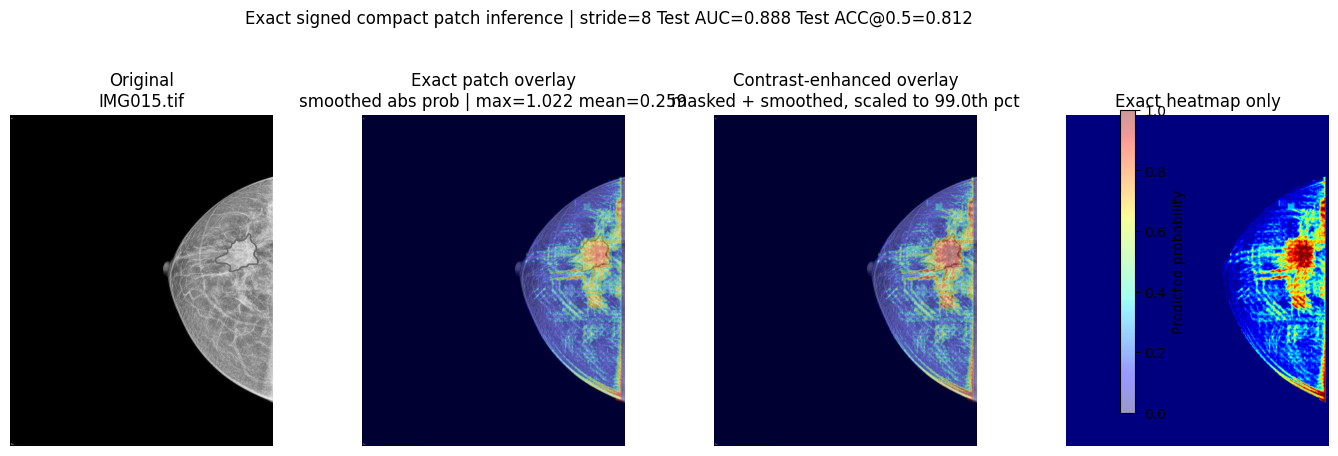

Exact heatmap stats: max=1.022230 mean_all=0.056572 mean_breast=0.258959
Exact heatmap grid size: (750, 595) with stride=8
Saved exact heatmap figure: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20/exact_patch_heatmap/IMG015_signed_exact_heatmap.png
Saved exact probability map: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20/exact_patch_heatmap/IMG015_signed_exact_prob_map.npy
Saved exact probability grid: results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/signed_compact_r20/exact_patch_heatmap/IMG015_signed_exact_prob_grid.npy


In [ ]:

# Exact patch-level heatmap for the signed compact model.
# This evaluates the same patch classifier used in training on a sliding grid over the image.
# It is slower than the fast dense map, but it is the correct full-image inference path.

EXACT_HEATMAP_STRIDE = 8
EXACT_HEATMAP_ROW_BLOCK = 24
EXACT_HEATMAP_BATCH_PATCHES = 128
EXACT_HEATMAP_MASK_THRESHOLD = 0.02
EXACT_HEATMAP_DISPLAY_PERCENTILE = 99.0
EXACT_HEATMAP_ALPHA = min(float(DENSE_OVERLAY_ALPHA), 0.55)
EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA = max(float(HEATMAP_SMOOTH_SIGMA), float(EXACT_HEATMAP_STRIDE) * 0.90)
EXACT_HEATMAP_BREAST_EROSION = max(2, RESIZE_PATCH // 12)
EXACT_HEATMAP_OUT_DIR = SIGNED_OUT_DIR / "exact_patch_heatmap"
EXACT_HEATMAP_OUT_DIR.mkdir(parents=True, exist_ok=True)

if "kernel_best_signed" not in globals():
    raise RuntimeError("Run the signed-identifiable-fit cell first.")

from scipy.ndimage import binary_erosion


def exact_signed_patch_prob_grid(
    image_np: np.ndarray,
    kernel_np: np.ndarray,
    patch_size: int,
    stride: int,
    batch_patches: int,
    row_block: int,
):
    image_t = to_tensor_batch(image_np[None, ...].astype(np.float32), torch.device("cpu"))
    h, w = image_np.shape

    pad_top = patch_size // 2
    pad_left = patch_size // 2
    pad_bottom = patch_size - pad_top - 1
    pad_right = patch_size - pad_left - 1
    padded = F.pad(image_t, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)

    y_positions = list(range(0, h, stride))
    x_positions = list(range(0, w, stride))
    feat_grid = np.zeros((len(y_positions), len(x_positions)), dtype=np.float32)
    kernel_t = torch.from_numpy(kernel_np).to(DEVICE)

    for row_start in range(0, len(y_positions), row_block):
        block_rows = y_positions[row_start : row_start + row_block]
        y0 = block_rows[0]
        y_last = block_rows[-1]
        crop_h = (len(block_rows) - 1) * stride + patch_size
        crop = padded[:, :, y0 : y0 + crop_h, :]

        patches_unfold = F.unfold(crop, kernel_size=(patch_size, patch_size), stride=(stride, stride))
        patches = patches_unfold.transpose(1, 2).reshape(-1, 1, patch_size, patch_size).contiguous()

        if STANDARDIZE_PATCHES:
            patches = patch_standardize(patches)

        block_feats = []
        for i in range(0, patches.shape[0], batch_patches):
            pb = patches[i : i + batch_patches].to(DEVICE, non_blocking=True)
            feat = signed_peak_response(pb, kernel_t)
            block_feats.append(feat.detach().cpu().numpy())

        block_feats = np.concatenate(block_feats, axis=0).astype(np.float32)
        feat_grid[row_start : row_start + len(block_rows), :] = block_feats.reshape(len(block_rows), len(x_positions))

    return feat_grid, np.array(y_positions, dtype=np.int64), np.array(x_positions, dtype=np.int64)


exact_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
exact_img_arr = np.array(Image.open(exact_example_path).convert("L"), dtype=np.float32) / 255.0

feat_grid_signed, y_grid_signed, x_grid_signed = exact_signed_patch_prob_grid(
    exact_img_arr,
    kernel_best_signed,
    patch_size=RESIZE_PATCH,
    stride=EXACT_HEATMAP_STRIDE,
    batch_patches=EXACT_HEATMAP_BATCH_PATCHES,
    row_block=EXACT_HEATMAP_ROW_BLOCK,
)

prob_grid_signed = sigmoid_np(
    calib_w_signed * ((feat_grid_signed - calib_mu_signed) / calib_std_signed) + calib_b_signed
).astype(np.float32)

prob_map_exact_signed = F.interpolate(
    torch.from_numpy(prob_grid_signed)[None, None],
    size=exact_img_arr.shape,
    mode="bicubic",
    align_corners=False,
)[0, 0].cpu().numpy().astype(np.float32)

h_img, w_img = exact_img_arr.shape
pad_top = RESIZE_PATCH // 2
pad_left = RESIZE_PATCH // 2
pad_bottom = RESIZE_PATCH - pad_top - 1
pad_right = RESIZE_PATCH - pad_left - 1
valid_center_mask_signed = np.zeros_like(exact_img_arr, dtype=np.float32)
valid_center_mask_signed[pad_top : h_img - pad_bottom, pad_left : w_img - pad_right] = 1.0

breast_mask_signed = exact_img_arr > float(EXACT_HEATMAP_MASK_THRESHOLD)
display_mask_signed = binary_erosion(
    breast_mask_signed,
    iterations=int(EXACT_HEATMAP_BREAST_EROSION),
).astype(np.float32)
display_mask_signed *= valid_center_mask_signed

smooth_num = gaussian_filter(
    prob_map_exact_signed * display_mask_signed,
    sigma=float(EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA),
)
smooth_den = gaussian_filter(display_mask_signed, sigma=float(EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA))
prob_map_exact_vis_signed = smooth_num / np.maximum(smooth_den, 1e-6)
prob_map_exact_vis_signed *= display_mask_signed

if display_mask_signed.any():
    masked_vals = prob_map_exact_vis_signed[display_mask_signed > 0]
    display_hi = float(np.percentile(masked_vals, EXACT_HEATMAP_DISPLAY_PERCENTILE))
else:
    masked_vals = prob_map_exact_vis_signed.ravel()
    display_hi = float(np.percentile(masked_vals, EXACT_HEATMAP_DISPLAY_PERCENTILE))

display_hi = max(display_hi, 1e-6)
prob_map_exact_display_signed = np.clip(prob_map_exact_vis_signed / display_hi, 0.0, 1.0).astype(np.float32)
prob_map_exact_display_signed *= display_mask_signed.astype(np.float32)

# Final display-only smoothing to remove residual stride artifacts after upsampling.
prob_map_exact_display_signed = gaussian_filter(
    prob_map_exact_display_signed,
    sigma=max(1.0, float(EXACT_HEATMAP_STRIDE) * 0.35),
).astype(np.float32)
prob_map_exact_display_signed *= display_mask_signed.astype(np.float32)
prob_map_exact_display_signed = np.clip(prob_map_exact_display_signed, 0.0, 1.0)

exact_score_max = float((prob_map_exact_signed * display_mask_signed).max())
exact_score_mean = float(prob_map_exact_signed.mean())
exact_score_mean_breast = float(masked_vals.mean()) if masked_vals.size > 0 else float(prob_map_exact_signed.mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(exact_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{exact_example_path.name}")
axes[0].axis("off")

axes[1].imshow(exact_img_arr, cmap="gray")
im1 = axes[1].imshow(
    prob_map_exact_vis_signed,
    cmap="jet",
    alpha=EXACT_HEATMAP_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[1].set_title(
    "Exact patch overlay\n"
    f"smoothed abs prob | max={exact_score_max:.3f} mean={exact_score_mean_breast:.3f}"
)
axes[1].axis("off")

axes[2].imshow(exact_img_arr, cmap="gray")
axes[2].imshow(
    prob_map_exact_display_signed,
    cmap="jet",
    alpha=EXACT_HEATMAP_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[2].set_title(
    "Contrast-enhanced overlay\n"
    f"masked + smoothed, scaled to {EXACT_HEATMAP_DISPLAY_PERCENTILE:.1f}th pct"
)
axes[2].axis("off")

axes[3].imshow(prob_map_exact_display_signed, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[3].set_title("Exact heatmap only")
axes[3].axis("off")

fig.suptitle(
    "Exact signed compact patch inference | "
    f"stride={EXACT_HEATMAP_STRIDE} "
    f"Test AUC={learned_results_signed['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_signed['test_05']['acc']:.3f}",
    y=1.02,
)

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.82)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.80, wspace=0.04)
plt.show()

print(f"Exact heatmap stats: max={exact_score_max:.6f} mean_all={exact_score_mean:.6f} mean_breast={exact_score_mean_breast:.6f}")
print(f"Exact heatmap grid size: {prob_grid_signed.shape} with stride={EXACT_HEATMAP_STRIDE}")

if SAVE_ARTIFACTS:
    exact_fig_path = EXACT_HEATMAP_OUT_DIR / f"{exact_example_path.stem}_signed_exact_heatmap.png"
    exact_prob_path = EXACT_HEATMAP_OUT_DIR / f"{exact_example_path.stem}_signed_exact_prob_map.npy"
    exact_prob_grid_path = EXACT_HEATMAP_OUT_DIR / f"{exact_example_path.stem}_signed_exact_prob_grid.npy"
    fig.savefig(exact_fig_path, dpi=260, bbox_inches="tight")
    np.save(exact_prob_path, prob_map_exact_signed)
    np.save(exact_prob_grid_path, prob_grid_signed)
    print(f"Saved exact heatmap figure: {exact_fig_path}")
    print(f"Saved exact probability map: {exact_prob_path}")
    print(f"Saved exact probability grid: {exact_prob_grid_path}")


## Independent Smooth Normalized Radial Training

This final section trains a new radial kernel from a generic decaying initialization instead of reusing a previously learned profile.
It uses a signed top-k response so the learned radial shape matters to accuracy much more than an absolute-max objective.
The profile remains normalized, monotone decreasing, and smooth to avoid spikes and unstable growth in the outer shells.


scratch epoch=01 loss=26.362743 val_auc=0.578481 val_acc=0.591444 w=+0.5120 b=-0.4997
scratch epoch=02 loss=8.128098 val_auc=0.905787 val_acc=0.636898 w=+0.0697 b=-0.9896
scratch epoch=03 loss=0.747189 val_auc=0.905667 val_acc=0.674332 w=+0.0164 b=-1.0974
scratch epoch=04 loss=0.626092 val_auc=0.905670 val_acc=0.760428 w=+0.0226 b=-1.1544
scratch epoch=05 loss=0.622900 val_auc=0.905671 val_acc=0.720321 w=+0.0251 b=-1.2227
scratch epoch=06 loss=0.620125 val_auc=0.905676 val_acc=0.822460 w=+0.0238 b=-1.3012
scratch epoch=07 loss=0.614809 val_auc=0.905677 val_acc=0.835829 w=+0.0232 b=-1.3848
scratch epoch=08 loss=0.611368 val_auc=0.905686 val_acc=0.742781 w=+0.0293 b=-1.4670
scratch epoch=09 loss=0.607301 val_auc=0.905690 val_acc=0.847059 w=+0.0267 b=-1.5613
scratch epoch=10 loss=0.604674 val_auc=0.905693 val_acc=0.843850 w=+0.0281 b=-1.6571
scratch epoch=11 loss=0.597866 val_auc=0.905694 val_acc=0.765775 w=+0.0340 b=-1.7505
scratch epoch=12 loss=0.595976 val_auc=0.905696 val_acc=0.841176

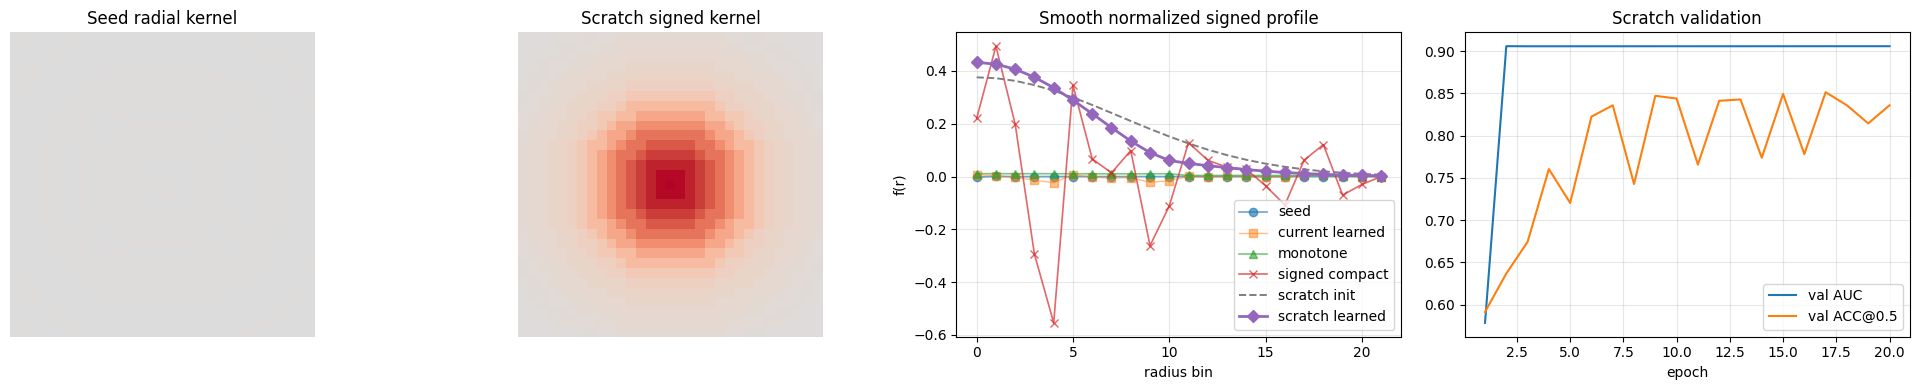

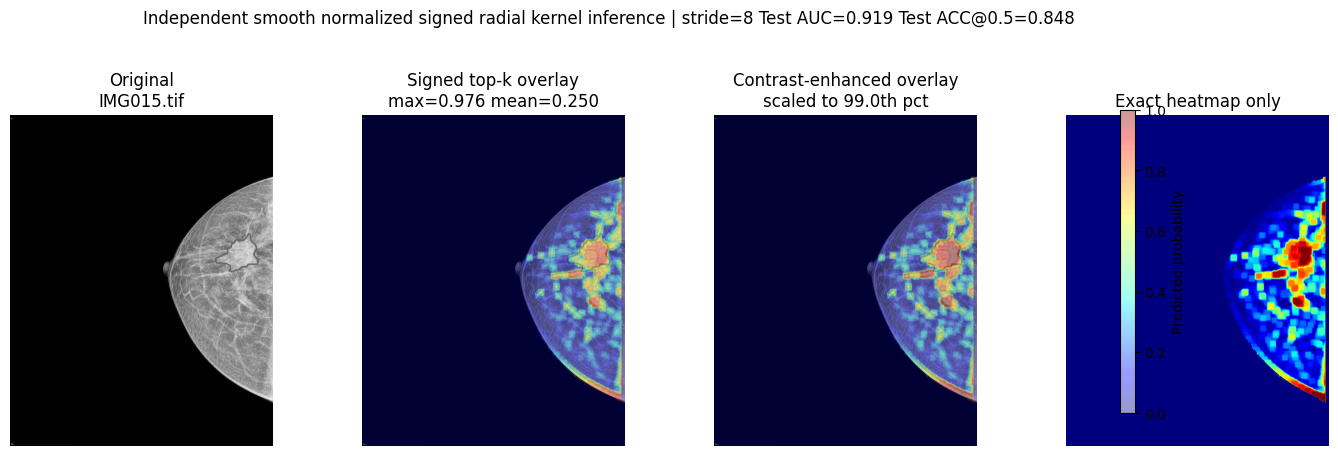

Scratch exact heatmap stats: max=0.976289 mean_all=0.052545 mean_breast=0.250472
Scratch exact heatmap grid size: (750, 595) with stride=8

Saved scratch signed monotone artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/scratch_monotone_normalized_signed


In [ ]:
# Optional: scratch monotone-normalized radial fit.
# This cell learns a fresh radial profile from a generic decaying initialization.
# It does not reuse coefficients from any previously trained kernel.
# The profile is constrained to be nonnegative, nonincreasing, smooth, and unit-norm.
# Unlike abs_max / mean_abs, the classifier uses a signed top-k response so the
# learned radial shape affects accuracy through the signed convolution pattern.

SCRATCH_RESPONSE_NAME = "signed_topk_mean"
SCRATCH_TOPK_RATIO = 0.01
SCRATCH_TOPK_MIN = 8
SCRATCH_TOPK_MAX = 128

SCRATCH_EPOCHS = max(EPOCHS, 20)
SCRATCH_LR_PROFILE = LR_F * 0.35
SCRATCH_LR_HEAD = LR_HEAD
SCRATCH_LAMBDA_SMOOTH = max(LAMBDA_SMOOTH, 2e-2)
SCRATCH_LAMBDA_CURVATURE = 5e-2
SCRATCH_LAMBDA_DECAY = 1e-1
SCRATCH_LAMBDA_EDGE = 1e-1
SCRATCH_OUT_DIR = OUT_DIR / "scratch_monotone_normalized_signed"
SCRATCH_OUT_DIR.mkdir(parents=True, exist_ok=True)

SCRATCH_EXACT_HEATMAP_STRIDE = 8
SCRATCH_EXACT_HEATMAP_ROW_BLOCK = 24
SCRATCH_EXACT_HEATMAP_BATCH_PATCHES = 128
SCRATCH_EXACT_HEATMAP_MASK_THRESHOLD = 0.02
SCRATCH_EXACT_HEATMAP_DISPLAY_PERCENTILE = 99.0
SCRATCH_EXACT_HEATMAP_ALPHA = min(float(DENSE_OVERLAY_ALPHA), 0.55)
SCRATCH_EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA = max(float(HEATMAP_SMOOTH_SIGMA), float(SCRATCH_EXACT_HEATMAP_STRIDE) * 0.90)
SCRATCH_EXACT_HEATMAP_BREAST_EROSION = max(2, RESIZE_PATCH // 12)
SCRATCH_EXACT_HEATMAP_OUT_DIR = SCRATCH_OUT_DIR / "exact_patch_heatmap"
SCRATCH_EXACT_HEATMAP_OUT_DIR.mkdir(parents=True, exist_ok=True)

scratch_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
scratch_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

scratch_len = full_radius_count
scratch_radius_np = np.linspace(0.0, 1.0, scratch_len, dtype=np.float32)
scratch_init = np.exp(-4.0 * (scratch_radius_np ** 2)).astype(np.float32)
scratch_init = scratch_init / max(float(np.linalg.norm(scratch_init)), 1e-8)
scratch_radius_t = torch.from_numpy(scratch_radius_np).to(DEVICE)


def scratch_inverse_softplus_np(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.maximum(x, 1e-6)
    return np.where(x > 20.0, x, np.log(np.expm1(x)))


def scratch_profile_from_raw(raw_delta_t: torch.Tensor):
    delta_t = F.softplus(raw_delta_t) + 1e-6
    profile_t = torch.flip(torch.cumsum(torch.flip(delta_t, dims=[0]), dim=0), dims=[0])
    profile_t = profile_t / (torch.norm(profile_t) + 1e-8)
    return profile_t


def scratch_signed_topk_response(
    x_t: torch.Tensor,
    kernel2d_t: torch.Tensor,
    topk_ratio: float = SCRATCH_TOPK_RATIO,
    topk_min: int = SCRATCH_TOPK_MIN,
    topk_max: int = SCRATCH_TOPK_MAX,
):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    flat = out[:, 0].reshape(out.shape[0], -1)
    total_positions = flat.shape[1]
    k = int(round(float(total_positions) * float(topk_ratio)))
    k = max(int(topk_min), k)
    k = min(int(topk_max), k, total_positions)
    idx = flat.abs().topk(k=k, dim=1).indices
    signed_topk = flat.gather(1, idx)
    return signed_topk.mean(dim=1)


@torch.no_grad()
def extract_scratch_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = scratch_signed_topk_response(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


scratch_delta_init = np.empty_like(scratch_init)
scratch_delta_init[:-1] = np.maximum(scratch_init[:-1] - scratch_init[1:], 1e-5)
scratch_delta_init[-1] = max(float(scratch_init[-1]), 1e-5)

scratch_raw_delta = torch.nn.Parameter(torch.from_numpy(scratch_inverse_softplus_np(scratch_delta_init)).to(DEVICE))
scratch_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
scratch_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

scratch_optimizer = torch.optim.Adam(
    [
        {"params": [scratch_raw_delta], "lr": SCRATCH_LR_PROFILE},
        {"params": [scratch_head_w, scratch_head_b], "lr": SCRATCH_LR_HEAD},
    ]
)
scratch_loss_fn = torch.nn.BCEWithLogitsLoss()
scratch_best_state = None
scratch_best_val_auc = -float("inf")
scratch_history = []

for epoch in range(1, SCRATCH_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in scratch_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        scratch_profile_t = scratch_profile_from_raw(scratch_raw_delta)
        scratch_kernel_t = torch.einsum("r,rhw->hw", scratch_profile_t, scratch_basis_t)
        scratch_feat = scratch_signed_topk_response(xb, scratch_kernel_t)
        scratch_logits = scratch_head_w * scratch_feat + scratch_head_b

        scratch_loss_cls = scratch_loss_fn(scratch_logits, yb)
        scratch_first_diff = scratch_profile_t[1:] - scratch_profile_t[:-1]
        scratch_loss_smooth = (
            torch.mean(scratch_first_diff ** 2)
            if scratch_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        scratch_second_diff = scratch_profile_t[2:] - 2.0 * scratch_profile_t[1:-1] + scratch_profile_t[:-2]
        scratch_loss_curvature = (
            torch.mean(scratch_second_diff ** 2)
            if scratch_len > 2
            else torch.tensor(0.0, device=DEVICE)
        )
        scratch_loss_decay = torch.mean((scratch_radius_t ** 2) * (scratch_profile_t ** 2))
        scratch_loss_edge = scratch_profile_t[-1] ** 2
        scratch_loss = (
            scratch_loss_cls
            + SCRATCH_LAMBDA_SMOOTH * scratch_loss_smooth
            + SCRATCH_LAMBDA_CURVATURE * scratch_loss_curvature
            + SCRATCH_LAMBDA_DECAY * scratch_loss_decay
            + SCRATCH_LAMBDA_EDGE * scratch_loss_edge
        )

        scratch_optimizer.zero_grad()
        scratch_loss.backward()
        scratch_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(scratch_loss.item()) * batch_n
        n_seen += batch_n

    scratch_profile_eval_t = scratch_profile_from_raw(scratch_raw_delta)
    scratch_kernel_eval_t = torch.einsum("r,rhw->hw", scratch_profile_eval_t, scratch_basis_t)
    scratch_val_resp = extract_scratch_responses(X_val_t, scratch_kernel_eval_t.detach(), BATCH_SIZE)
    scratch_val_probs = sigmoid_np(
        float(scratch_head_w.detach().cpu()) * scratch_val_resp + float(scratch_head_b.detach().cpu())
    )
    scratch_val_metrics = metrics_from_probs(y_val, scratch_val_probs, threshold=0.5)

    scratch_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(scratch_val_metrics["auc"]),
            "val_acc": float(scratch_val_metrics["acc"]),
            "optimizer_head_w": float(scratch_head_w.detach().cpu()),
            "optimizer_head_b": float(scratch_head_b.detach().cpu()),
        }
    )

    if scratch_val_metrics["auc"] > scratch_best_val_auc:
        scratch_best_val_auc = scratch_val_metrics["auc"]
        scratch_best_state = {
            "epoch": int(epoch),
            "raw_delta": scratch_raw_delta.detach().cpu().clone(),
            "optimizer_head_w": float(scratch_head_w.detach().cpu()),
            "optimizer_head_b": float(scratch_head_b.detach().cpu()),
            "val_auc": float(scratch_val_metrics["auc"]),
            "val_acc": float(scratch_val_metrics["acc"]),
        }

    print(
        f"scratch epoch={epoch:02d} "
        f"loss={scratch_history[-1]['loss']:.6f} "
        f"val_auc={scratch_val_metrics['auc']:.6f} "
        f"val_acc={scratch_val_metrics['acc']:.6f} "
        f"w={float(scratch_head_w.detach().cpu()):+.4f} "
        f"b={float(scratch_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best scratch checkpoint:")
print(scratch_best_state)

scratch_raw_best = scratch_best_state["raw_delta"].to(DEVICE)
scratch_optimizer_head_w_best = float(scratch_best_state["optimizer_head_w"])
scratch_optimizer_head_b_best = float(scratch_best_state["optimizer_head_b"])

with torch.no_grad():
    f_best_full_scratch_t = scratch_profile_from_raw(scratch_raw_best)
    kernel_best_scratch_t = torch.einsum("r,rhw->hw", f_best_full_scratch_t, scratch_basis_t)

f_best_full_scratch = f_best_full_scratch_t.detach().cpu().numpy().astype(np.float32)
kernel_best_scratch = kernel_best_scratch_t.detach().cpu().numpy().astype(np.float32)

train_resp_scratch = extract_scratch_responses(X_train_t, kernel_best_scratch_t.detach(), BATCH_SIZE)
val_resp_scratch = extract_scratch_responses(X_val_t, kernel_best_scratch_t.detach(), BATCH_SIZE)
test_resp_scratch = extract_scratch_responses(X_test_t, kernel_best_scratch_t.detach(), BATCH_SIZE)

calib_mu_scratch = float(train_resp_scratch.mean())
calib_std_scratch = float(train_resp_scratch.std())
calib_std_scratch = calib_std_scratch if calib_std_scratch > 1e-8 else 1.0

calib_clf_scratch = LogisticRegression(max_iter=1000)
calib_clf_scratch.fit(((train_resp_scratch - calib_mu_scratch) / calib_std_scratch).reshape(-1, 1), y_train)

calib_w_scratch = float(calib_clf_scratch.coef_[0, 0])
calib_b_scratch = float(calib_clf_scratch.intercept_[0])

train_probs_scratch = calib_clf_scratch.predict_proba(
    ((train_resp_scratch - calib_mu_scratch) / calib_std_scratch).reshape(-1, 1)
)[:, 1]
val_probs_scratch = calib_clf_scratch.predict_proba(
    ((val_resp_scratch - calib_mu_scratch) / calib_std_scratch).reshape(-1, 1)
)[:, 1]
test_probs_scratch = calib_clf_scratch.predict_proba(
    ((test_resp_scratch - calib_mu_scratch) / calib_std_scratch).reshape(-1, 1)
)[:, 1]

scratch_threshold_val, scratch_val_acc_tuned = best_threshold_by_accuracy(
    y_val,
    val_probs_scratch,
    THRESHOLD_GRID_SIZE,
)

learned_results_scratch = {
    "val_05": metrics_from_probs(y_val, val_probs_scratch, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_scratch, threshold=scratch_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_scratch, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_scratch, threshold=scratch_threshold_val),
    "threshold_val": float(scratch_threshold_val),
    "best_epoch": int(scratch_best_state["epoch"]),
    "optimizer_head_w": scratch_optimizer_head_w_best,
    "optimizer_head_b": scratch_optimizer_head_b_best,
    "calib_mu": calib_mu_scratch,
    "calib_std": calib_std_scratch,
    "calib_w": calib_w_scratch,
    "calib_b": calib_b_scratch,
    "response_name": SCRATCH_RESPONSE_NAME,
    "topk_ratio": float(SCRATCH_TOPK_RATIO),
    "topk_min": int(SCRATCH_TOPK_MIN),
    "topk_max": int(SCRATCH_TOPK_MAX),
}

print("\nCalibrated scratch signed radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_scratch['val_05']['auc']:.6f} ACC@0.5={learned_results_scratch['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_scratch['val_tuned']['acc']:.6f} (thr_val={learned_results_scratch['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_scratch['test_05']['auc']:.6f} ACC@0.5={learned_results_scratch['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_scratch['test_tuned']['acc']:.6f}"
)

print("\nScratch radial coefficients:")
for idx, value in enumerate(f_best_full_scratch):
    print(f"  f{idx:02d} = {value:+.7e}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
scratch_vmax = max(
    float(np.max(np.abs(seed_radial_kernel))),
    float(np.max(np.abs(kernel_best_scratch))),
    float(np.max(np.abs(kernel_best))) if "kernel_best" in globals() else 0.0,
) + 1e-12

axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-scratch_vmax, vmax=scratch_vmax)
axes[0].set_title("Seed radial kernel")
axes[0].axis("off")

axes[1].imshow(kernel_best_scratch, cmap="coolwarm", vmin=-scratch_vmax, vmax=scratch_vmax)
axes[1].set_title("Scratch signed kernel")
axes[1].axis("off")

axes[2].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.2, alpha=0.65, label="seed")
if "f_best_full" in globals():
    axes[2].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.0, alpha=0.5, label="current learned")
if "f_best_full_mono" in globals():
    axes[2].plot(np.arange(len(f_best_full_mono)), f_best_full_mono, marker="^", linewidth=1.2, alpha=0.6, label="monotone")
if "f_best_full_signed" in globals():
    axes[2].plot(np.arange(len(f_best_full_signed)), f_best_full_signed, marker="x", linewidth=1.2, alpha=0.7, label="signed compact")
axes[2].plot(np.arange(len(scratch_init)), scratch_init, linestyle="--", linewidth=1.4, color="tab:gray", label="scratch init")
axes[2].plot(np.arange(len(f_best_full_scratch)), f_best_full_scratch, marker="D", linewidth=2.0, label="scratch learned")
axes[2].set_xlabel("radius bin")
axes[2].set_ylabel("f(r)")
axes[2].set_title("Smooth normalized signed profile")
axes[2].grid(alpha=0.3)
axes[2].legend()

scratch_epochs = np.array([row["epoch"] for row in scratch_history], dtype=int)
scratch_val_auc_curve = np.array([row["val_auc"] for row in scratch_history], dtype=np.float32)
scratch_val_acc_curve = np.array([row["val_acc"] for row in scratch_history], dtype=np.float32)
axes[3].plot(scratch_epochs, scratch_val_auc_curve, label="val AUC")
axes[3].plot(scratch_epochs, scratch_val_acc_curve, label="val ACC@0.5")
axes[3].set_xlabel("epoch")
axes[3].set_title("Scratch validation")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

from scipy.ndimage import binary_erosion


def exact_scratch_patch_prob_grid(
    image_np: np.ndarray,
    kernel_np: np.ndarray,
    patch_size: int,
    stride: int,
    batch_patches: int,
    row_block: int,
):
    image_t = to_tensor_batch(image_np[None, ...].astype(np.float32), torch.device("cpu"))
    h, w = image_np.shape

    pad_top = patch_size // 2
    pad_left = patch_size // 2
    pad_bottom = patch_size - pad_top - 1
    pad_right = patch_size - pad_left - 1
    padded = F.pad(image_t, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)

    y_positions = list(range(0, h, stride))
    x_positions = list(range(0, w, stride))
    feat_grid = np.zeros((len(y_positions), len(x_positions)), dtype=np.float32)
    kernel_t = torch.from_numpy(kernel_np).to(DEVICE)

    for row_start in range(0, len(y_positions), row_block):
        block_rows = y_positions[row_start : row_start + row_block]
        y0 = block_rows[0]
        crop_h = (len(block_rows) - 1) * stride + patch_size
        crop = padded[:, :, y0 : y0 + crop_h, :]

        patches_unfold = F.unfold(crop, kernel_size=(patch_size, patch_size), stride=(stride, stride))
        patches = patches_unfold.transpose(1, 2).reshape(-1, 1, patch_size, patch_size).contiguous()

        if STANDARDIZE_PATCHES:
            patches = patch_standardize(patches)

        block_feats = []
        for i in range(0, patches.shape[0], batch_patches):
            pb = patches[i : i + batch_patches].to(DEVICE, non_blocking=True)
            feat = scratch_signed_topk_response(pb, kernel_t)
            block_feats.append(feat.detach().cpu().numpy())

        block_feats = np.concatenate(block_feats, axis=0).astype(np.float32)
        feat_grid[row_start : row_start + len(block_rows), :] = block_feats.reshape(len(block_rows), len(x_positions))

    return feat_grid, np.array(y_positions, dtype=np.int64), np.array(x_positions, dtype=np.int64)


scratch_example_path = ensure_example_image(EXAMPLE_IMAGE_PATH)
scratch_img_arr = np.array(Image.open(scratch_example_path).convert("L"), dtype=np.float32) / 255.0

feat_grid_scratch, y_grid_scratch, x_grid_scratch = exact_scratch_patch_prob_grid(
    scratch_img_arr,
    kernel_best_scratch,
    patch_size=RESIZE_PATCH,
    stride=SCRATCH_EXACT_HEATMAP_STRIDE,
    batch_patches=SCRATCH_EXACT_HEATMAP_BATCH_PATCHES,
    row_block=SCRATCH_EXACT_HEATMAP_ROW_BLOCK,
)

prob_grid_scratch = sigmoid_np(
    calib_w_scratch * ((feat_grid_scratch - calib_mu_scratch) / calib_std_scratch) + calib_b_scratch
).astype(np.float32)

prob_map_exact_scratch = F.interpolate(
    torch.from_numpy(prob_grid_scratch)[None, None],
    size=scratch_img_arr.shape,
    mode="bicubic",
    align_corners=False,
)[0, 0].cpu().numpy().astype(np.float32)

h_img, w_img = scratch_img_arr.shape
pad_top = RESIZE_PATCH // 2
pad_left = RESIZE_PATCH // 2
pad_bottom = RESIZE_PATCH - pad_top - 1
pad_right = RESIZE_PATCH - pad_left - 1
valid_center_mask_scratch = np.zeros_like(scratch_img_arr, dtype=np.float32)
valid_center_mask_scratch[pad_top : h_img - pad_bottom, pad_left : w_img - pad_right] = 1.0

breast_mask_scratch = scratch_img_arr > float(SCRATCH_EXACT_HEATMAP_MASK_THRESHOLD)
display_mask_scratch = binary_erosion(
    breast_mask_scratch,
    iterations=int(SCRATCH_EXACT_HEATMAP_BREAST_EROSION),
).astype(np.float32)
display_mask_scratch *= valid_center_mask_scratch

smooth_num = gaussian_filter(
    prob_map_exact_scratch * display_mask_scratch,
    sigma=float(SCRATCH_EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA),
)
smooth_den = gaussian_filter(display_mask_scratch, sigma=float(SCRATCH_EXACT_HEATMAP_EXTRA_SMOOTH_SIGMA))
prob_map_exact_vis_scratch = smooth_num / np.maximum(smooth_den, 1e-6)
prob_map_exact_vis_scratch *= display_mask_scratch

if display_mask_scratch.any():
    masked_vals = prob_map_exact_vis_scratch[display_mask_scratch > 0]
    display_hi = float(np.percentile(masked_vals, SCRATCH_EXACT_HEATMAP_DISPLAY_PERCENTILE))
else:
    masked_vals = prob_map_exact_vis_scratch.ravel()
    display_hi = float(np.percentile(masked_vals, SCRATCH_EXACT_HEATMAP_DISPLAY_PERCENTILE))

display_hi = max(display_hi, 1e-6)
prob_map_exact_display_scratch = np.clip(prob_map_exact_vis_scratch / display_hi, 0.0, 1.0).astype(np.float32)
prob_map_exact_display_scratch *= display_mask_scratch.astype(np.float32)
prob_map_exact_display_scratch = gaussian_filter(
    prob_map_exact_display_scratch,
    sigma=max(1.0, float(SCRATCH_EXACT_HEATMAP_STRIDE) * 0.35),
).astype(np.float32)
prob_map_exact_display_scratch *= display_mask_scratch.astype(np.float32)
prob_map_exact_display_scratch = np.clip(prob_map_exact_display_scratch, 0.0, 1.0)

scratch_score_max = float((prob_map_exact_scratch * display_mask_scratch).max())
scratch_score_mean = float(prob_map_exact_scratch.mean())
scratch_score_mean_breast = float(masked_vals.mean()) if masked_vals.size > 0 else float(prob_map_exact_scratch.mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(scratch_img_arr, cmap="gray")
axes[0].set_title(f"Original\n{scratch_example_path.name}")
axes[0].axis("off")

axes[1].imshow(scratch_img_arr, cmap="gray")
scratch_im = axes[1].imshow(
    prob_map_exact_vis_scratch,
    cmap="jet",
    alpha=SCRATCH_EXACT_HEATMAP_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[1].set_title(
    "Signed top-k overlay\n"
    f"max={scratch_score_max:.3f} mean={scratch_score_mean_breast:.3f}"
)
axes[1].axis("off")

axes[2].imshow(scratch_img_arr, cmap="gray")
axes[2].imshow(
    prob_map_exact_display_scratch,
    cmap="jet",
    alpha=SCRATCH_EXACT_HEATMAP_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[2].set_title(
    "Contrast-enhanced overlay\n"
    f"scaled to {SCRATCH_EXACT_HEATMAP_DISPLAY_PERCENTILE:.1f}th pct"
)
axes[2].axis("off")

axes[3].imshow(prob_map_exact_display_scratch, cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[3].set_title("Exact heatmap only")
axes[3].axis("off")

fig.suptitle(
    "Independent smooth normalized signed radial kernel inference | "
    f"stride={SCRATCH_EXACT_HEATMAP_STRIDE} "
    f"Test AUC={learned_results_scratch['test_05']['auc']:.3f} "
    f"Test ACC@0.5={learned_results_scratch['test_05']['acc']:.3f}",
    y=1.02,
)

cbar = fig.colorbar(scratch_im, ax=axes.ravel().tolist(), shrink=0.82)
cbar.set_label("Predicted probability")
fig.subplots_adjust(top=0.80, wspace=0.04)
plt.show()

print(
    f"Scratch exact heatmap stats: max={scratch_score_max:.6f} "
    f"mean_all={scratch_score_mean:.6f} "
    f"mean_breast={scratch_score_mean_breast:.6f}"
)
print(f"Scratch exact heatmap grid size: {prob_grid_scratch.shape} with stride={SCRATCH_EXACT_HEATMAP_STRIDE}")

scratch_summary = {
    "scratch_init_profile": [float(x) for x in scratch_init],
    "f_scratch_full": [float(x) for x in f_best_full_scratch],
    "learned_scratch": learned_results_scratch,
    "history_scratch": scratch_history,
    "response_name": SCRATCH_RESPONSE_NAME,
    "constraints": {
        "nonnegative": True,
        "monotone_decreasing": True,
        "unit_norm": True,
    },
}

if SAVE_ARTIFACTS:
    np.save(SCRATCH_OUT_DIR / "f_scratch_init.npy", scratch_init.astype(np.float32))
    np.save(SCRATCH_OUT_DIR / "f_scratch_full.npy", f_best_full_scratch.astype(np.float32))
    np.save(SCRATCH_OUT_DIR / "kernel_scratch_monotone_signed.npy", kernel_best_scratch.astype(np.float32))
    np.save(SCRATCH_EXACT_HEATMAP_OUT_DIR / f"{scratch_example_path.stem}_scratch_exact_prob_map.npy", prob_map_exact_scratch)
    np.save(SCRATCH_EXACT_HEATMAP_OUT_DIR / f"{scratch_example_path.stem}_scratch_exact_prob_grid.npy", prob_grid_scratch)
    fig.savefig(SCRATCH_EXACT_HEATMAP_OUT_DIR / f"{scratch_example_path.stem}_scratch_exact_heatmap.png", dpi=260, bbox_inches="tight")
    (SCRATCH_OUT_DIR / "scratch_monotone_summary.json").write_text(json.dumps(scratch_summary, indent=2))
    print(f"\nSaved scratch signed monotone artifacts to {SCRATCH_OUT_DIR}")


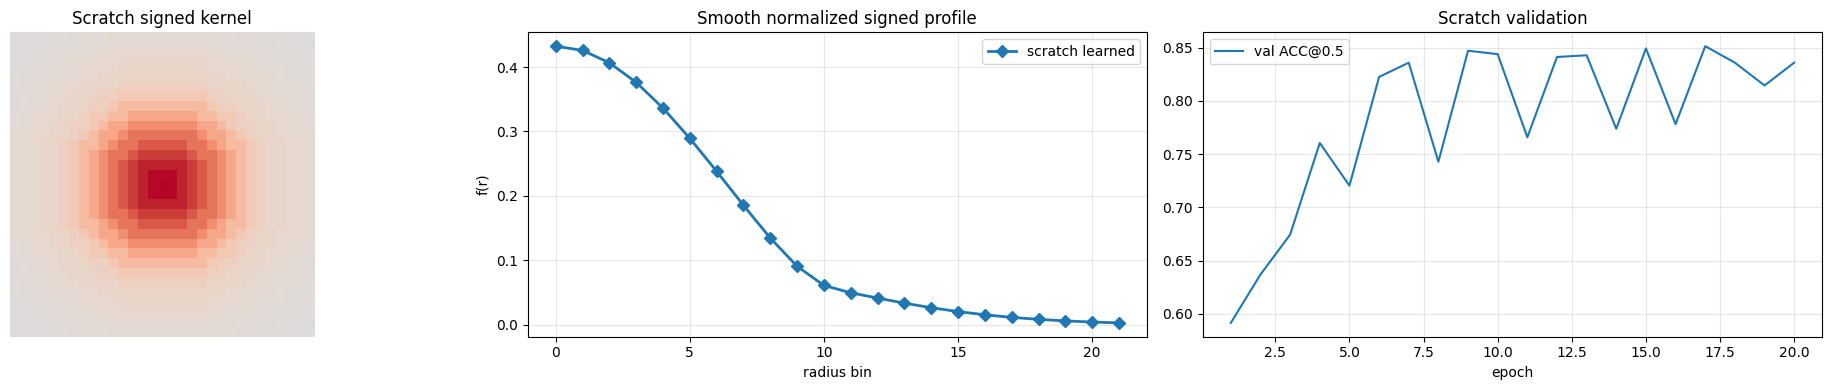

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
scratch_vmax = max(
    float(np.max(np.abs(seed_radial_kernel))),
    float(np.max(np.abs(kernel_best_scratch))),
    float(np.max(np.abs(kernel_best))) if "kernel_best" in globals() else 0.0,
) + 1e-12

# axes[0].imshow(seed_radial_kernel, cmap="coolwarm", vmin=-scratch_vmax, vmax=scratch_vmax)
# axes[0].set_title("Seed radial kernel")
# axes[0].axis("off")

axes[0].imshow(kernel_best_scratch, cmap="coolwarm", vmin=-scratch_vmax, vmax=scratch_vmax)
axes[0].set_title("Scratch signed kernel")
axes[0].axis("off")

# axes[1].plot(np.arange(len(f_seed_full)), f_seed_full, marker="o", linewidth=1.2, alpha=0.65, label="seed")
# if "f_best_full" in globals():
#     axes[1].plot(np.arange(len(f_best_full)), f_best_full, marker="s", linewidth=1.0, alpha=0.5, label="current learned")
# if "f_best_full_mono" in globals():
#     axes[1].plot(np.arange(len(f_best_full_mono)), f_best_full_mono, marker="^", linewidth=1.2, alpha=0.6, label="monotone")
# if "f_best_full_signed" in globals():
#     axes[1].plot(np.arange(len(f_best_full_signed)), f_best_full_signed, marker="x", linewidth=1.2, alpha=0.7, label="signed compact")
# axes[1].plot(np.arange(len(scratch_init)), scratch_init, linestyle="--", linewidth=1.4, color="tab:gray", label="scratch init")
axes[1].plot(np.arange(len(f_best_full_scratch)), f_best_full_scratch, marker="D", linewidth=2.0, label="scratch learned")
axes[1].set_xlabel("radius bin")
axes[1].set_ylabel("f(r)")
axes[1].set_title("Smooth normalized signed profile")
axes[1].grid(alpha=0.3)
axes[1].legend()

scratch_epochs = np.array([row["epoch"] for row in scratch_history], dtype=int)
# scratch_val_auc_curve = np.array([row["val_auc"] for row in scratch_history], dtype=np.float32)
scratch_val_acc_curve = np.array([row["val_acc"] for row in scratch_history], dtype=np.float32)
# axes[2].plot(scratch_epochs, scratch_val_auc_curve, label="val AUC")
axes[2].plot(scratch_epochs, scratch_val_acc_curve, label="val ACC@0.5")
axes[2].set_xlabel("epoch")
axes[2].set_title("Scratch validation")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


free epoch=01 loss=6.487120 val_auc=0.746253 val_acc=0.607487 w=+0.6595 b=-0.1141
free epoch=02 loss=1.214687 val_auc=0.649776 val_acc=0.650267 w=+0.5310 b=-0.2801
free epoch=03 loss=0.852589 val_auc=0.683284 val_acc=0.656150 w=+0.4547 b=-0.4339
free epoch=04 loss=0.754107 val_auc=0.672636 val_acc=0.651872 w=+0.3893 b=-0.5979
free epoch=05 loss=0.689470 val_auc=0.680513 val_acc=0.633690 w=+0.3402 b=-0.7638
free epoch=06 loss=0.662793 val_auc=0.747982 val_acc=0.670588 w=+0.3042 b=-0.9208
free epoch=07 loss=0.645372 val_auc=0.821326 val_acc=0.688770 w=+0.2849 b=-1.0657
free epoch=08 loss=0.639398 val_auc=0.861959 val_acc=0.767914 w=+0.2742 b=-1.2080
free epoch=09 loss=0.632026 val_auc=0.882053 val_acc=0.811765 w=+0.2729 b=-1.3434
free epoch=10 loss=0.626122 val_auc=0.890333 val_acc=0.827273 w=+0.2745 b=-1.4754
free epoch=11 loss=0.618687 val_auc=0.892969 val_acc=0.828877 w=+0.2776 b=-1.6060
free epoch=12 loss=0.611102 val_auc=0.893909 val_acc=0.834759 w=+0.2796 b=-1.7410
free epoch=13 lo

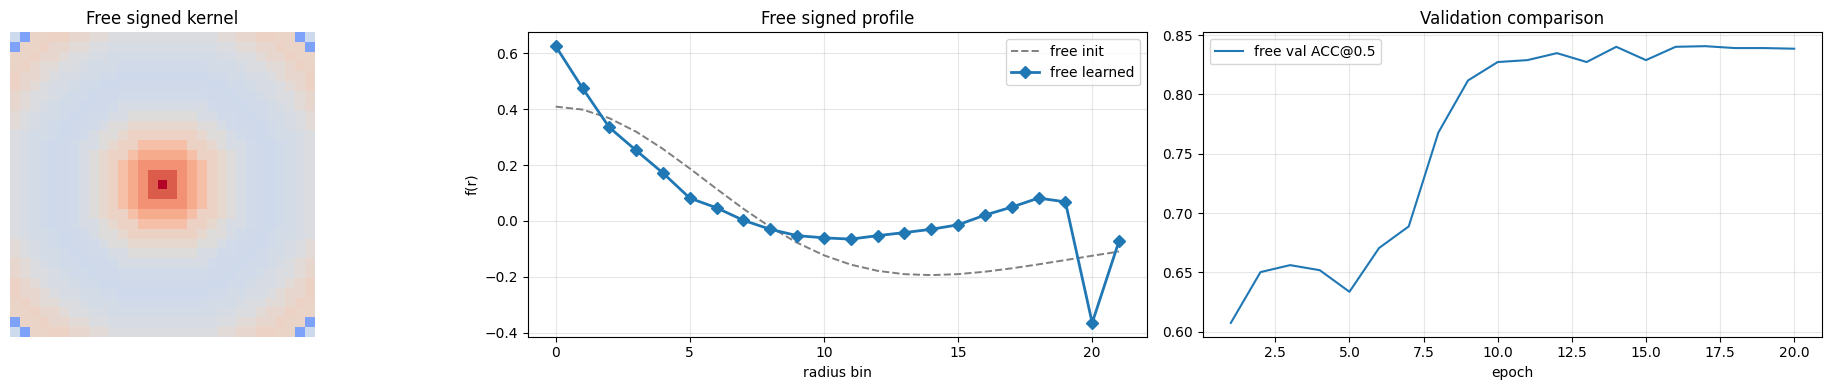


Saved free signed artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/scratch_free_signed


In [ ]:
# Optional: independent signed radial fit without positivity / monotonicity constraints.
# This ablation keeps the signed top-k objective, but removes the positive and
# monotone profile construction to test whether a free signed radial profile
# gives better quality than the averaging-like constrained fit.

FREE_RESPONSE_NAME = "signed_topk_mean_free_profile"
FREE_TOPK_RATIO = SCRATCH_TOPK_RATIO if "SCRATCH_TOPK_RATIO" in globals() else 0.01
FREE_TOPK_MIN = SCRATCH_TOPK_MIN if "SCRATCH_TOPK_MIN" in globals() else 8
FREE_TOPK_MAX = SCRATCH_TOPK_MAX if "SCRATCH_TOPK_MAX" in globals() else 128

FREE_EPOCHS = max(EPOCHS, 20)
FREE_LR_PROFILE = LR_F * 0.35
FREE_LR_HEAD = LR_HEAD
FREE_LAMBDA_SMOOTH = max(LAMBDA_SMOOTH, 2e-2)
FREE_LAMBDA_CURVATURE = 5e-2
FREE_LAMBDA_DECAY = 1e-1
FREE_LAMBDA_EDGE = 1e-1
FREE_OUT_DIR = OUT_DIR / "scratch_free_signed"
FREE_OUT_DIR.mkdir(parents=True, exist_ok=True)

free_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
free_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

free_len = full_radius_count
free_radius_np = np.linspace(0.0, 1.0, free_len, dtype=np.float32)
free_radius_t = torch.from_numpy(free_radius_np).to(DEVICE)

# Signed difference-of-Gaussians style initialization to avoid starting from
# an all-positive averaging filter while still remaining independent.
free_init = (
    np.exp(-6.0 * (free_radius_np ** 2))
    - 0.55 * np.exp(-1.5 * (free_radius_np ** 2))
).astype(np.float32)
if np.linalg.norm(free_init) < 1e-8:
    free_init[0] = 1.0
free_init = free_init / max(float(np.linalg.norm(free_init)), 1e-8)


def free_signed_topk_response(
    x_t: torch.Tensor,
    kernel2d_t: torch.Tensor,
    topk_ratio: float = FREE_TOPK_RATIO,
    topk_min: int = FREE_TOPK_MIN,
    topk_max: int = FREE_TOPK_MAX,
):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    flat = out[:, 0].reshape(out.shape[0], -1)
    total_positions = flat.shape[1]
    k = int(round(float(total_positions) * float(topk_ratio)))
    k = max(int(topk_min), k)
    k = min(int(topk_max), k, total_positions)
    idx = flat.abs().topk(k=k, dim=1).indices
    signed_topk = flat.gather(1, idx)
    return signed_topk.mean(dim=1)


@torch.no_grad()
def extract_free_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = free_signed_topk_response(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


def free_profile_from_param(profile_param_t: torch.Tensor):
    return profile_param_t / (torch.norm(profile_param_t) + 1e-8)


free_profile_param = torch.nn.Parameter(torch.from_numpy(free_init).to(DEVICE))
free_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
free_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

free_optimizer = torch.optim.Adam(
    [
        {"params": [free_profile_param], "lr": FREE_LR_PROFILE},
        {"params": [free_head_w, free_head_b], "lr": FREE_LR_HEAD},
    ]
)
free_loss_fn = torch.nn.BCEWithLogitsLoss()
free_best_state = None
free_best_val_auc = -float("inf")
free_history = []

for epoch in range(1, FREE_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in free_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        free_profile_t = free_profile_from_param(free_profile_param)
        free_kernel_t = torch.einsum("r,rhw->hw", free_profile_t, free_basis_t)
        free_feat = free_signed_topk_response(xb, free_kernel_t)
        free_logits = free_head_w * free_feat + free_head_b

        free_loss_cls = free_loss_fn(free_logits, yb)
        free_first_diff = free_profile_t[1:] - free_profile_t[:-1]
        free_loss_smooth = (
            torch.mean(free_first_diff ** 2)
            if free_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        free_second_diff = free_profile_t[2:] - 2.0 * free_profile_t[1:-1] + free_profile_t[:-2]
        free_loss_curvature = (
            torch.mean(free_second_diff ** 2)
            if free_len > 2
            else torch.tensor(0.0, device=DEVICE)
        )
        free_loss_decay = torch.mean((free_radius_t ** 2) * (free_profile_t ** 2))
        free_loss_edge = free_profile_t[-1] ** 2
        free_loss = (
            free_loss_cls
            + FREE_LAMBDA_SMOOTH * free_loss_smooth
            + FREE_LAMBDA_CURVATURE * free_loss_curvature
            + FREE_LAMBDA_DECAY * free_loss_decay
            + FREE_LAMBDA_EDGE * free_loss_edge
        )

        free_optimizer.zero_grad()
        free_loss.backward()
        free_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(free_loss.item()) * batch_n
        n_seen += batch_n

    free_profile_eval_t = free_profile_from_param(free_profile_param)
    free_kernel_eval_t = torch.einsum("r,rhw->hw", free_profile_eval_t, free_basis_t)
    free_val_resp = extract_free_responses(X_val_t, free_kernel_eval_t.detach(), BATCH_SIZE)
    free_val_probs = sigmoid_np(
        float(free_head_w.detach().cpu()) * free_val_resp + float(free_head_b.detach().cpu())
    )
    free_val_metrics = metrics_from_probs(y_val, free_val_probs, threshold=0.5)

    free_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(free_val_metrics["auc"]),
            "val_acc": float(free_val_metrics["acc"]),
            "optimizer_head_w": float(free_head_w.detach().cpu()),
            "optimizer_head_b": float(free_head_b.detach().cpu()),
        }
    )

    if free_val_metrics["auc"] > free_best_val_auc:
        free_best_val_auc = free_val_metrics["auc"]
        free_best_state = {
            "epoch": int(epoch),
            "profile_param": free_profile_param.detach().cpu().clone(),
            "optimizer_head_w": float(free_head_w.detach().cpu()),
            "optimizer_head_b": float(free_head_b.detach().cpu()),
            "val_auc": float(free_val_metrics["auc"]),
            "val_acc": float(free_val_metrics["acc"]),
        }

    print(
        f"free epoch={epoch:02d} "
        f"loss={free_history[-1]['loss']:.6f} "
        f"val_auc={free_val_metrics['auc']:.6f} "
        f"val_acc={free_val_metrics['acc']:.6f} "
        f"w={float(free_head_w.detach().cpu()):+.4f} "
        f"b={float(free_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best free-profile checkpoint:")
print(free_best_state)

free_profile_best_param = free_best_state["profile_param"].to(DEVICE)
free_optimizer_head_w_best = float(free_best_state["optimizer_head_w"])
free_optimizer_head_b_best = float(free_best_state["optimizer_head_b"])

with torch.no_grad():
    f_best_full_free_t = free_profile_from_param(free_profile_best_param)
    kernel_best_free_t = torch.einsum("r,rhw->hw", f_best_full_free_t, free_basis_t)

f_best_full_free = f_best_full_free_t.detach().cpu().numpy().astype(np.float32)
kernel_best_free = kernel_best_free_t.detach().cpu().numpy().astype(np.float32)

train_resp_free = extract_free_responses(X_train_t, kernel_best_free_t.detach(), BATCH_SIZE)
val_resp_free = extract_free_responses(X_val_t, kernel_best_free_t.detach(), BATCH_SIZE)
test_resp_free = extract_free_responses(X_test_t, kernel_best_free_t.detach(), BATCH_SIZE)

calib_mu_free = float(train_resp_free.mean())
calib_std_free = float(train_resp_free.std())
calib_std_free = calib_std_free if calib_std_free > 1e-8 else 1.0

calib_clf_free = LogisticRegression(max_iter=1000)
calib_clf_free.fit(((train_resp_free - calib_mu_free) / calib_std_free).reshape(-1, 1), y_train)

calib_w_free = float(calib_clf_free.coef_[0, 0])
calib_b_free = float(calib_clf_free.intercept_[0])

train_probs_free = calib_clf_free.predict_proba(
    ((train_resp_free - calib_mu_free) / calib_std_free).reshape(-1, 1)
)[:, 1]
val_probs_free = calib_clf_free.predict_proba(
    ((val_resp_free - calib_mu_free) / calib_std_free).reshape(-1, 1)
)[:, 1]
test_probs_free = calib_clf_free.predict_proba(
    ((test_resp_free - calib_mu_free) / calib_std_free).reshape(-1, 1)
)[:, 1]

free_threshold_val, free_val_acc_tuned = best_threshold_by_accuracy(
    y_val,
    val_probs_free,
    THRESHOLD_GRID_SIZE,
)

learned_results_free = {
    "val_05": metrics_from_probs(y_val, val_probs_free, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_free, threshold=free_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_free, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_free, threshold=free_threshold_val),
    "threshold_val": float(free_threshold_val),
    "best_epoch": int(free_best_state["epoch"]),
    "optimizer_head_w": free_optimizer_head_w_best,
    "optimizer_head_b": free_optimizer_head_b_best,
    "calib_mu": calib_mu_free,
    "calib_std": calib_std_free,
    "calib_w": calib_w_free,
    "calib_b": calib_b_free,
    "response_name": FREE_RESPONSE_NAME,
    "topk_ratio": float(FREE_TOPK_RATIO),
    "topk_min": int(FREE_TOPK_MIN),
    "topk_max": int(FREE_TOPK_MAX),
}

print("\nCalibrated free signed radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_free['val_05']['auc']:.6f} ACC@0.5={learned_results_free['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_free['val_tuned']['acc']:.6f} (thr_val={learned_results_free['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_free['test_05']['auc']:.6f} ACC@0.5={learned_results_free['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_free['test_tuned']['acc']:.6f}"
)

if "learned_results_scratch" in globals():
    print("\nComparison against constrained scratch fit:")
    print(
        f"  constrained test ACC@0.5={learned_results_scratch['test_05']['acc']:.6f} "
        f"AUC={learned_results_scratch['test_05']['auc']:.6f}"
    )
    print(
        f"  free        test ACC@0.5={learned_results_free['test_05']['acc']:.6f} "
        f"AUC={learned_results_free['test_05']['auc']:.6f}"
    )

print("\nFree signed radial coefficients:")
for idx, value in enumerate(f_best_full_free):
    print(f"  f{idx:02d} = {value:+.7e}")

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
free_vmax = max(
    float(np.max(np.abs(kernel_best_free))),
    float(np.max(np.abs(kernel_best_scratch))) if "kernel_best_scratch" in globals() else 0.0,
    float(np.max(np.abs(seed_radial_kernel))),
) + 1e-12

axes[0].imshow(kernel_best_free, cmap="coolwarm", vmin=-free_vmax, vmax=free_vmax)
axes[0].set_title("Free signed kernel")
axes[0].axis("off")

axes[1].plot(np.arange(len(free_init)), free_init, linestyle="--", linewidth=1.4, color="tab:gray", label="free init")
if "f_best_full_scratch" in globals():
    axes[1].plot(
        np.arange(len(f_best_full_scratch)),
        f_best_full_scratch,
        linewidth=1.6,
        alpha=0.75,
        label="constrained scratch",
    )
axes[1].plot(np.arange(len(f_best_full_free)), f_best_full_free, marker="D", linewidth=2.0, label="free learned")
axes[1].set_xlabel("radius bin")
axes[1].set_ylabel("f(r)")
axes[1].set_title("Free signed profile")
axes[1].grid(alpha=0.3)
axes[1].legend()

free_epochs = np.array([row["epoch"] for row in free_history], dtype=int)
free_val_acc_curve = np.array([row["val_acc"] for row in free_history], dtype=np.float32)
axes[2].plot(free_epochs, free_val_acc_curve, label="free val ACC@0.5")
if "scratch_history" in globals():
    scratch_val_acc_curve = np.array([row["val_acc"] for row in scratch_history], dtype=np.float32)
    scratch_epochs = np.array([row["epoch"] for row in scratch_history], dtype=int)
    axes[2].plot(scratch_epochs, scratch_val_acc_curve, alpha=0.7, label="constrained val ACC@0.5")
axes[2].set_xlabel("epoch")
axes[2].set_title("Validation comparison")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

free_summary = {
    "free_init_profile": [float(x) for x in free_init],
    "f_free_full": [float(x) for x in f_best_full_free],
    "learned_free": learned_results_free,
    "history_free": free_history,
    "response_name": FREE_RESPONSE_NAME,
    "constraints": {
        "nonnegative": False,
        "monotone_decreasing": False,
        "unit_norm": True,
    },
}

if SAVE_ARTIFACTS:
    np.save(FREE_OUT_DIR / "f_free_init.npy", free_init.astype(np.float32))
    np.save(FREE_OUT_DIR / "f_free_full.npy", f_best_full_free.astype(np.float32))
    np.save(FREE_OUT_DIR / "kernel_free_signed.npy", kernel_best_free.astype(np.float32))
    (FREE_OUT_DIR / "free_signed_summary.json").write_text(json.dumps(free_summary, indent=2))
    print(f"\nSaved free signed artifacts to {FREE_OUT_DIR}")


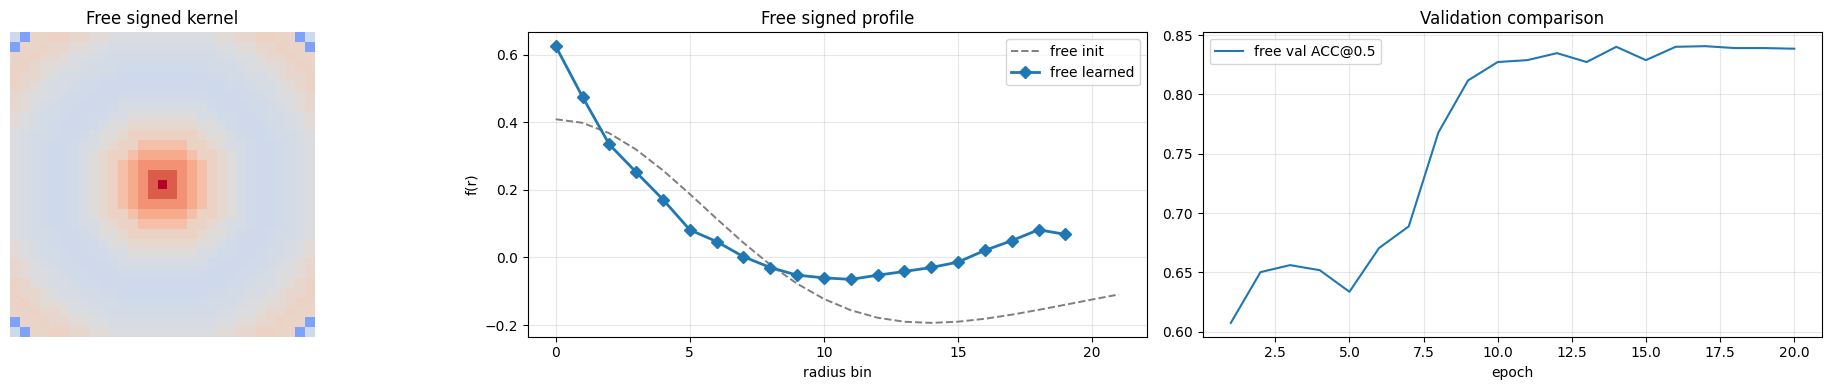

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
free_vmax = max(
    float(np.max(np.abs(kernel_best_free))),
    float(np.max(np.abs(kernel_best_scratch))) if "kernel_best_scratch" in globals() else 0.0,
    float(np.max(np.abs(seed_radial_kernel))),
) + 1e-12

axes[0].imshow(kernel_best_free, cmap="coolwarm", vmin=-free_vmax, vmax=free_vmax)
axes[0].set_title("Free signed kernel")
axes[0].axis("off")

axes[1].plot(np.arange(len(free_init)), free_init, linestyle="--", linewidth=1.4, color="tab:gray", label="free init")
if "f_best_full_scratch" in globals():
    axes[1].plot(
        np.arange(len(f_best_full_scratch)),
        f_best_full_scratch,
        linewidth=1.6,
        alpha=0.75,
        label="constrained scratch",
    )
axes[1].plot(np.arange(len(f_best_full_free[:-2])), f_best_full_free[:-2], marker="D", linewidth=2.0, label="free learned")
axes[1].set_xlabel("radius bin")
axes[1].set_ylabel("f(r)")
axes[1].set_title("Free signed profile")
axes[1].grid(alpha=0.3)
axes[1].legend()

free_epochs = np.array([row["epoch"] for row in free_history], dtype=int)
free_val_acc_curve = np.array([row["val_acc"] for row in free_history], dtype=np.float32)
axes[2].plot(free_epochs, free_val_acc_curve, label="free val ACC@0.5")
if "scratch_history" in globals():
    scratch_val_acc_curve = np.array([row["val_acc"] for row in scratch_history], dtype=np.float32)
    scratch_epochs = np.array([row["epoch"] for row in scratch_history], dtype=int)
    axes[2].plot(scratch_epochs, scratch_val_acc_curve, alpha=0.7, label="constrained val ACC@0.5")
axes[2].set_xlabel("epoch")
axes[2].set_title("Validation comparison")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


## Signed Radial Training With Learnable Radius

This section learns a signed radial profile together with a differentiable radius/support parameter, so the optimizer can change both the radial values and the effective kernel size.
The profile remains normalized, but it is not constrained to be positive or monotone.


radius epoch=01 loss=8.362045 val_auc=0.901051 val_acc=0.577540 radius=13.317 w=+0.7293 b=+0.0340
radius epoch=02 loss=0.965020 val_auc=0.638788 val_acc=0.627807 radius=13.283 w=+0.6791 b=-0.1317
radius epoch=03 loss=0.697288 val_auc=0.618986 val_acc=0.597326 radius=13.275 w=+0.6703 b=-0.2455
radius epoch=04 loss=0.692334 val_auc=0.589338 val_acc=0.553476 radius=13.266 w=+0.6610 b=-0.3756
radius epoch=05 loss=0.699347 val_auc=0.645897 val_acc=0.609091 radius=13.252 w=+0.6470 b=-0.5215
radius epoch=06 loss=0.669587 val_auc=0.653910 val_acc=0.603209 radius=13.242 w=+0.6367 b=-0.6676
radius epoch=07 loss=0.669373 val_auc=0.665299 val_acc=0.606952 radius=13.230 w=+0.6245 b=-0.8216
radius epoch=08 loss=0.673388 val_auc=0.738521 val_acc=0.666845 radius=13.215 w=+0.6081 b=-0.9845
radius epoch=09 loss=0.652557 val_auc=0.740945 val_acc=0.676471 radius=13.203 w=+0.5934 b=-1.1413
radius epoch=10 loss=0.634420 val_auc=0.797133 val_acc=0.696257 radius=13.195 w=+0.5832 b=-1.2924
radius epoch=11 loss

radius epoch=12 loss=0.612356 val_auc=0.835006 val_acc=0.732086 radius=13.183 w=+0.5657 b=-1.5887
radius epoch=13 loss=0.605596 val_auc=0.810534 val_acc=0.725668 radius=13.179 w=+0.5589 b=-1.7313
radius epoch=14 loss=0.590294 val_auc=0.908994 val_acc=0.803209 radius=13.181 w=+0.5582 b=-1.8637
radius epoch=15 loss=0.586167 val_auc=0.908502 val_acc=0.812299 radius=13.183 w=+0.5577 b=-1.9983
radius epoch=16 loss=0.583135 val_auc=0.908933 val_acc=0.848128 radius=13.184 w=+0.5569 b=-2.1370
radius epoch=17 loss=0.578814 val_auc=0.907025 val_acc=0.850802 radius=13.184 w=+0.5565 b=-2.2742
radius epoch=18 loss=0.574017 val_auc=0.909896 val_acc=0.819786 radius=13.184 w=+0.5564 b=-2.4093
radius epoch=19 loss=0.568308 val_auc=0.911280 val_acc=0.830481 radius=13.183 w=+0.5556 b=-2.5496
radius epoch=20 loss=0.562639 val_auc=0.912747 val_acc=0.812299 radius=13.181 w=+0.5551 b=-2.6905

Restoring best learnable-radius checkpoint:
{'epoch': 20, 'profile_param': tensor([ 0.7018,  0.5800,  0.5478,  0.3756

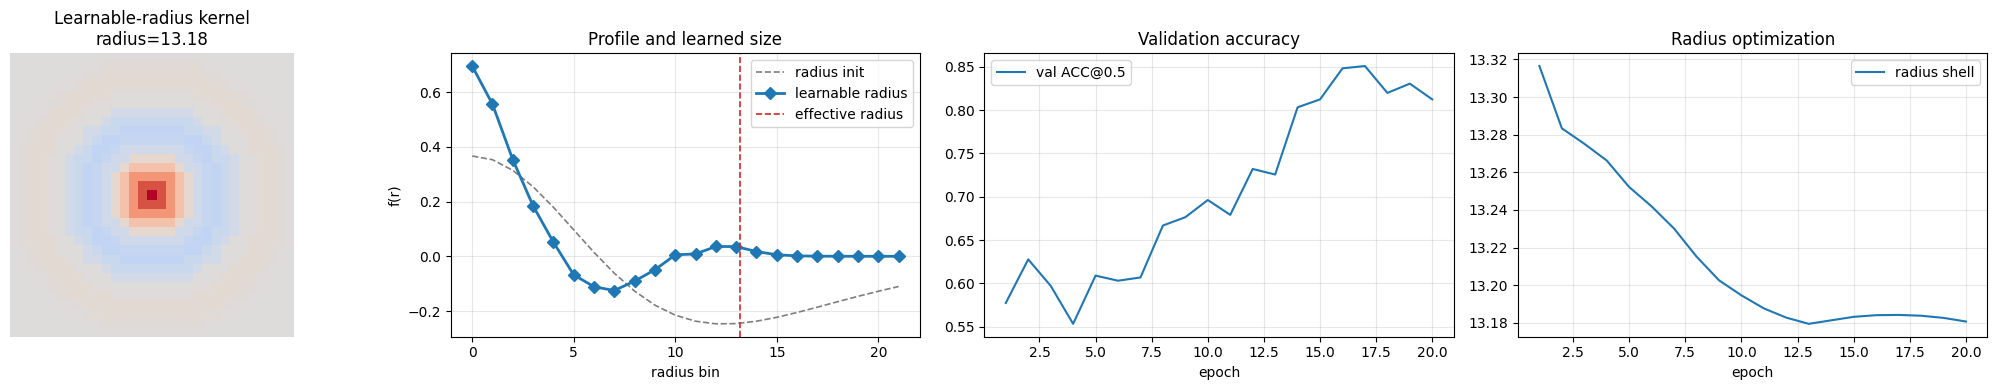


Saved learnable-radius artifacts to results/exp_022_mmr_nperFamily500_nComposition1250/radial_single_kernel_r20/scratch_learnable_radius_signed


In [7]:
# Optional: signed normalized radial fit with learnable radius / support.
# This cell optimizes both:
# 1) a signed radial profile with positive and negative values allowed
# 2) an effective radius/support parameter that can shrink or expand the kernel
# The final profile is L2-normalized, but it is not forced to be positive or monotone.

RADIUS_RESPONSE_NAME = "signed_topk_mean_learnable_radius"
RADIUS_TOPK_RATIO = SCRATCH_TOPK_RATIO if "SCRATCH_TOPK_RATIO" in globals() else 0.01
RADIUS_TOPK_MIN = SCRATCH_TOPK_MIN if "SCRATCH_TOPK_MIN" in globals() else 8
RADIUS_TOPK_MAX = SCRATCH_TOPK_MAX if "SCRATCH_TOPK_MAX" in globals() else 128

RADIUS_EPOCHS = max(EPOCHS, 20)
RADIUS_LR_PROFILE = LR_F * 0.30
RADIUS_LR_RADIUS = LR_F * 0.10
RADIUS_LR_HEAD = LR_HEAD
RADIUS_LAMBDA_SMOOTH = max(LAMBDA_SMOOTH, 1e-2)
RADIUS_LAMBDA_CURVATURE = 2e-2
RADIUS_LAMBDA_EDGE = 5e-2
RADIUS_LAMBDA_OUTER = 5e-2
RADIUS_GATE_TEMP = 0.75
RADIUS_MIN_SHELL = 2.0
RADIUS_MAX_SHELL = float(full_radius_count - 1)
RADIUS_OUT_DIR = OUT_DIR / "scratch_learnable_radius_signed"
RADIUS_OUT_DIR.mkdir(parents=True, exist_ok=True)

radius_basis_t = basis_t if "basis_t" in globals() else torch.from_numpy(basis_np).to(DEVICE)
radius_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

radius_len = full_radius_count
radius_shell_t = torch.arange(radius_len, dtype=torch.float32, device=DEVICE)
radius_shell_np = np.arange(radius_len, dtype=np.float32)
radius_shell_norm_np = radius_shell_np / max(float(radius_len - 1), 1.0)

# Signed, radius-centered initialization so the optimizer does not start from an
# averaging-like all-positive kernel.
radius_init = (
    np.exp(-7.5 * (radius_shell_norm_np ** 2))
    - 0.60 * np.exp(-1.6 * (radius_shell_norm_np ** 2))
).astype(np.float32)
if np.linalg.norm(radius_init) < 1e-8:
    radius_init[0] = 1.0
radius_init = radius_init / max(float(np.linalg.norm(radius_init)), 1e-8)


def radius_inverse_sigmoid_scalar(prob_value: float):
    prob_value = min(max(float(prob_value), 1e-4), 1.0 - 1e-4)
    return float(np.log(prob_value / (1.0 - prob_value)))


def radius_parameter_to_shell(raw_radius_t: torch.Tensor):
    return RADIUS_MIN_SHELL + (RADIUS_MAX_SHELL - RADIUS_MIN_SHELL) * torch.sigmoid(raw_radius_t)


def radius_signed_topk_response(
    x_t: torch.Tensor,
    kernel2d_t: torch.Tensor,
    topk_ratio: float = RADIUS_TOPK_RATIO,
    topk_min: int = RADIUS_TOPK_MIN,
    topk_max: int = RADIUS_TOPK_MAX,
):
    out = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    flat = out[:, 0].reshape(out.shape[0], -1)
    total_positions = flat.shape[1]
    k = int(round(float(total_positions) * float(topk_ratio)))
    k = max(int(topk_min), k)
    k = min(int(topk_max), k, total_positions)
    idx = flat.abs().topk(k=k, dim=1).indices
    signed_topk = flat.gather(1, idx)
    return signed_topk.mean(dim=1)


@torch.no_grad()
def extract_radius_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = radius_signed_topk_response(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0,), dtype=np.float32)


def interpolate_radius_profile(control_t: torch.Tensor, sample_pos_t: torch.Tensor):
    pos_t = torch.clamp(sample_pos_t, 0.0, float(control_t.numel() - 1))
    idx0 = torch.floor(pos_t).long()
    idx1 = torch.clamp(idx0 + 1, max=control_t.numel() - 1)
    frac_t = pos_t - idx0.to(pos_t.dtype)
    return (1.0 - frac_t) * control_t[idx0] + frac_t * control_t[idx1]


def build_radius_scaled_kernel(profile_param_t: torch.Tensor, raw_radius_t: torch.Tensor):
    radius_shell_value_t = radius_parameter_to_shell(raw_radius_t)
    base_profile_t = profile_param_t / (torch.norm(profile_param_t) + 1e-8)
    scaled_pos_t = (radius_shell_t / torch.clamp(radius_shell_value_t, min=1e-6)) * float(radius_len - 1)
    sampled_profile_t = interpolate_radius_profile(base_profile_t, scaled_pos_t)
    support_gate_t = torch.sigmoid((radius_shell_value_t - radius_shell_t) / RADIUS_GATE_TEMP)
    full_profile_t = sampled_profile_t * support_gate_t
    full_profile_t = full_profile_t / (torch.norm(full_profile_t) + 1e-8)
    kernel_t = torch.einsum("r,rhw->hw", full_profile_t, radius_basis_t)
    return kernel_t, full_profile_t, radius_shell_value_t, support_gate_t


radius_profile_param = torch.nn.Parameter(torch.from_numpy(radius_init).to(DEVICE))
radius_init_fraction = (0.65 * RADIUS_MAX_SHELL - RADIUS_MIN_SHELL) / max(RADIUS_MAX_SHELL - RADIUS_MIN_SHELL, 1e-6)
radius_raw_shell = torch.nn.Parameter(
    torch.tensor(radius_inverse_sigmoid_scalar(radius_init_fraction), dtype=torch.float32, device=DEVICE)
)
radius_head_w = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float32, device=DEVICE))
radius_head_b = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=DEVICE))

radius_optimizer = torch.optim.Adam(
    [
        {"params": [radius_profile_param], "lr": RADIUS_LR_PROFILE},
        {"params": [radius_raw_shell], "lr": RADIUS_LR_RADIUS},
        {"params": [radius_head_w, radius_head_b], "lr": RADIUS_LR_HEAD},
    ]
)
radius_loss_fn = torch.nn.BCEWithLogitsLoss()
radius_best_state = None
radius_best_val_auc = -float("inf")
radius_history = []

for epoch in range(1, RADIUS_EPOCHS + 1):
    total_loss = 0.0
    n_seen = 0

    for xb, yb in radius_train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        radius_kernel_t, radius_profile_t, radius_shell_value_t, radius_gate_t = build_radius_scaled_kernel(
            radius_profile_param,
            radius_raw_shell,
        )
        radius_feat = radius_signed_topk_response(xb, radius_kernel_t)
        radius_logits = radius_head_w * radius_feat + radius_head_b

        radius_loss_cls = radius_loss_fn(radius_logits, yb)
        radius_first_diff = radius_profile_t[1:] - radius_profile_t[:-1]
        radius_loss_smooth = (
            torch.mean(radius_first_diff ** 2)
            if radius_len > 1
            else torch.tensor(0.0, device=DEVICE)
        )
        radius_second_diff = radius_profile_t[2:] - 2.0 * radius_profile_t[1:-1] + radius_profile_t[:-2]
        radius_loss_curvature = (
            torch.mean(radius_second_diff ** 2)
            if radius_len > 2
            else torch.tensor(0.0, device=DEVICE)
        )
        radius_loss_edge = radius_profile_t[-1] ** 2
        radius_loss_outer = torch.mean((radius_shell_t / max(float(radius_len - 1), 1.0)) ** 2 * (radius_profile_t ** 2))
        radius_loss = (
            radius_loss_cls
            + RADIUS_LAMBDA_SMOOTH * radius_loss_smooth
            + RADIUS_LAMBDA_CURVATURE * radius_loss_curvature
            + RADIUS_LAMBDA_EDGE * radius_loss_edge
            + RADIUS_LAMBDA_OUTER * radius_loss_outer
        )

        radius_optimizer.zero_grad()
        radius_loss.backward()
        radius_optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(radius_loss.item()) * batch_n
        n_seen += batch_n

    radius_kernel_eval_t, radius_profile_eval_t, radius_shell_eval_t, _ = build_radius_scaled_kernel(
        radius_profile_param,
        radius_raw_shell,
    )
    radius_val_resp = extract_radius_responses(X_val_t, radius_kernel_eval_t.detach(), BATCH_SIZE)
    radius_val_probs = sigmoid_np(
        float(radius_head_w.detach().cpu()) * radius_val_resp + float(radius_head_b.detach().cpu())
    )
    radius_val_metrics = metrics_from_probs(y_val, radius_val_probs, threshold=0.5)

    radius_history.append(
        {
            "epoch": int(epoch),
            "loss": float(total_loss / max(n_seen, 1)),
            "val_auc": float(radius_val_metrics["auc"]),
            "val_acc": float(radius_val_metrics["acc"]),
            "radius_shell": float(radius_shell_eval_t.detach().cpu()),
            "optimizer_head_w": float(radius_head_w.detach().cpu()),
            "optimizer_head_b": float(radius_head_b.detach().cpu()),
        }
    )

    if radius_val_metrics["auc"] > radius_best_val_auc:
        radius_best_val_auc = radius_val_metrics["auc"]
        radius_best_state = {
            "epoch": int(epoch),
            "profile_param": radius_profile_param.detach().cpu().clone(),
            "raw_radius": radius_raw_shell.detach().cpu().clone(),
            "optimizer_head_w": float(radius_head_w.detach().cpu()),
            "optimizer_head_b": float(radius_head_b.detach().cpu()),
            "val_auc": float(radius_val_metrics["auc"]),
            "val_acc": float(radius_val_metrics["acc"]),
            "radius_shell": float(radius_shell_eval_t.detach().cpu()),
        }

    print(
        f"radius epoch={epoch:02d} "
        f"loss={radius_history[-1]['loss']:.6f} "
        f"val_auc={radius_val_metrics['auc']:.6f} "
        f"val_acc={radius_val_metrics['acc']:.6f} "
        f"radius={float(radius_shell_eval_t.detach().cpu()):.3f} "
        f"w={float(radius_head_w.detach().cpu()):+.4f} "
        f"b={float(radius_head_b.detach().cpu()):+.4f}"
    )

print("\nRestoring best learnable-radius checkpoint:")
print(radius_best_state)

radius_best_profile_param = radius_best_state["profile_param"].to(DEVICE)
radius_best_raw_shell = radius_best_state["raw_radius"].to(DEVICE)
radius_optimizer_head_w_best = float(radius_best_state["optimizer_head_w"])
radius_optimizer_head_b_best = float(radius_best_state["optimizer_head_b"])

with torch.no_grad():
    kernel_best_radius_t, f_best_full_radius_t, radius_shell_best_t, radius_gate_best_t = build_radius_scaled_kernel(
        radius_best_profile_param,
        radius_best_raw_shell,
    )

kernel_best_radius = kernel_best_radius_t.detach().cpu().numpy().astype(np.float32)
f_best_full_radius = f_best_full_radius_t.detach().cpu().numpy().astype(np.float32)
radius_shell_best = float(radius_shell_best_t.detach().cpu())
radius_gate_best = radius_gate_best_t.detach().cpu().numpy().astype(np.float32)

train_resp_radius = extract_radius_responses(X_train_t, kernel_best_radius_t.detach(), BATCH_SIZE)
val_resp_radius = extract_radius_responses(X_val_t, kernel_best_radius_t.detach(), BATCH_SIZE)
test_resp_radius = extract_radius_responses(X_test_t, kernel_best_radius_t.detach(), BATCH_SIZE)

calib_mu_radius = float(train_resp_radius.mean())
calib_std_radius = float(train_resp_radius.std())
calib_std_radius = calib_std_radius if calib_std_radius > 1e-8 else 1.0

calib_clf_radius = LogisticRegression(max_iter=1000)
calib_clf_radius.fit(((train_resp_radius - calib_mu_radius) / calib_std_radius).reshape(-1, 1), y_train)

calib_w_radius = float(calib_clf_radius.coef_[0, 0])
calib_b_radius = float(calib_clf_radius.intercept_[0])

train_probs_radius = calib_clf_radius.predict_proba(
    ((train_resp_radius - calib_mu_radius) / calib_std_radius).reshape(-1, 1)
)[:, 1]
val_probs_radius = calib_clf_radius.predict_proba(
    ((val_resp_radius - calib_mu_radius) / calib_std_radius).reshape(-1, 1)
)[:, 1]
test_probs_radius = calib_clf_radius.predict_proba(
    ((test_resp_radius - calib_mu_radius) / calib_std_radius).reshape(-1, 1)
)[:, 1]

radius_threshold_val, radius_val_acc_tuned = best_threshold_by_accuracy(
    y_val,
    val_probs_radius,
    THRESHOLD_GRID_SIZE,
)

learned_results_radius = {
    "val_05": metrics_from_probs(y_val, val_probs_radius, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs_radius, threshold=radius_threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs_radius, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs_radius, threshold=radius_threshold_val),
    "threshold_val": float(radius_threshold_val),
    "best_epoch": int(radius_best_state["epoch"]),
    "optimizer_head_w": radius_optimizer_head_w_best,
    "optimizer_head_b": radius_optimizer_head_b_best,
    "calib_mu": calib_mu_radius,
    "calib_std": calib_std_radius,
    "calib_w": calib_w_radius,
    "calib_b": calib_b_radius,
    "response_name": RADIUS_RESPONSE_NAME,
    "radius_shell": float(radius_shell_best),
}

print("\nCalibrated signed learnable-radius radial-kernel metrics:")
print(
    f"  Val  | AUC={learned_results_radius['val_05']['auc']:.6f} ACC@0.5={learned_results_radius['val_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_radius['val_tuned']['acc']:.6f} (thr_val={learned_results_radius['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={learned_results_radius['test_05']['auc']:.6f} ACC@0.5={learned_results_radius['test_05']['acc']:.6f} "
    f"ACC@thr_val={learned_results_radius['test_tuned']['acc']:.6f}"
)
print(f"\nLearned effective radius shell: {radius_shell_best:.3f}")

print("\nLearnable-radius signed radial coefficients:")
for idx, value in enumerate(f_best_full_radius):
    print(f"  f{idx:02d} = {value:+.7e}")

fig, axes = plt.subplots(1, 4, figsize=(21, 4))
radius_vmax = max(
    float(np.max(np.abs(kernel_best_radius))),
    float(np.max(np.abs(kernel_best_free))) if "kernel_best_free" in globals() else 0.0,
    float(np.max(np.abs(kernel_best_scratch))) if "kernel_best_scratch" in globals() else 0.0,
    float(np.max(np.abs(seed_radial_kernel))),
) + 1e-12

axes[0].imshow(kernel_best_radius, cmap="coolwarm", vmin=-radius_vmax, vmax=radius_vmax)
axes[0].set_title(f"Learnable-radius kernel\nradius={radius_shell_best:.2f}")
axes[0].axis("off")

if "f_best_full_free" in globals():
    axes[1].plot(np.arange(len(f_best_full_free)), f_best_full_free, linewidth=1.2, alpha=0.75, label="free signed")
if "f_best_full_scratch" in globals():
    axes[1].plot(np.arange(len(f_best_full_scratch)), f_best_full_scratch, linewidth=1.2, alpha=0.75, label="constrained")
axes[1].plot(np.arange(len(radius_init)), radius_init, linestyle="--", color="tab:gray", linewidth=1.2, label="radius init")
axes[1].plot(np.arange(len(f_best_full_radius)), f_best_full_radius, marker="D", linewidth=2.0, label="learnable radius")
axes[1].axvline(radius_shell_best, color="tab:red", linestyle="--", linewidth=1.2, label="effective radius")
axes[1].set_xlabel("radius bin")
axes[1].set_ylabel("f(r)")
axes[1].set_title("Profile and learned size")
axes[1].grid(alpha=0.3)
axes[1].legend()

radius_epochs = np.array([row["epoch"] for row in radius_history], dtype=int)
radius_val_acc_curve = np.array([row["val_acc"] for row in radius_history], dtype=np.float32)
radius_shell_curve = np.array([row["radius_shell"] for row in radius_history], dtype=np.float32)
axes[2].plot(radius_epochs, radius_val_acc_curve, label="val ACC@0.5")
axes[2].set_xlabel("epoch")
axes[2].set_title("Validation accuracy")
axes[2].grid(alpha=0.3)
axes[2].legend()

axes[3].plot(radius_epochs, radius_shell_curve, label="radius shell")
axes[3].set_xlabel("epoch")
axes[3].set_title("Radius optimization")
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

learnable_radius_summary = {
    "radius_init_profile": [float(x) for x in radius_init],
    "f_radius_full": [float(x) for x in f_best_full_radius],
    "radius_gate": [float(x) for x in radius_gate_best],
    "learned_radius": learned_results_radius,
    "history_radius": radius_history,
    "radius_shell": float(radius_shell_best),
    "response_name": RADIUS_RESPONSE_NAME,
    "constraints": {
        "nonnegative": False,
        "monotone_decreasing": False,
        "unit_norm": True,
    },
}

if SAVE_ARTIFACTS:
    np.save(RADIUS_OUT_DIR / "f_radius_init.npy", radius_init.astype(np.float32))
    np.save(RADIUS_OUT_DIR / "f_radius_full.npy", f_best_full_radius.astype(np.float32))
    np.save(RADIUS_OUT_DIR / "radius_gate.npy", radius_gate_best.astype(np.float32))
    np.save(RADIUS_OUT_DIR / "kernel_learnable_radius_signed.npy", kernel_best_radius.astype(np.float32))
    (RADIUS_OUT_DIR / "learnable_radius_summary.json").write_text(json.dumps(learnable_radius_summary, indent=2))
    print(f"\nSaved learnable-radius artifacts to {RADIUS_OUT_DIR}")
